# **Introducción al análisis de datos en Python** 
#### Profesor: Lucas Gómez Tobón

## Clase 6. Repaso de pandas y visualizaciones

### Manipulación de fechas

In [1]:
import os 
import pandas as pd

In [2]:
os.getcwd()

'c:\\Users\\Lucas\\OneDrive - Universidad de los Andes\\Complementarias\\Proyectos de analítica en Python\\Introducción al análisis de datos en Python\\Clase 6\\Scripts'

In [3]:
# ¿Qué significan los dos puntos?
os.chdir("../Datos")

In [4]:
os.getcwd()

'c:\\Users\\Lucas\\OneDrive - Universidad de los Andes\\Complementarias\\Proyectos de analítica en Python\\Introducción al análisis de datos en Python\\Clase 6\\Datos'

In [5]:
os.listdir()

['info_accidentes.xlsx']

In [6]:
accidentes1 = pd.read_excel('info_accidentes.xlsx', sheet_name = 'parteA') 
accidentes2 = pd.read_excel('info_accidentes.xlsx', sheet_name = 'parteB') 

# Hace un inner join
accidentes = pd.merge(accidentes1, accidentes2, on = ['Direccion', 'Fecha'])

Note que cuando inspeccionamos nuestra base, las columnas `Fecha` y `HoraOcurrencia` son de tipo `object` o sea texto. Sin embargo, las fechas tienen un tipo particular en `pandas` y para poder operar correctamente estas columnas, debemos formatearlas en tipo `datetime`. 

In [7]:
accidentes[["Fecha", "HoraOcurrencia"]].head()

,Fecha,HoraOcurrencia
0,01/13/2016 12:00:00 AM,12/31/1899 10:30:00 PM
1,2016-12-01 00:00:00,12/31/1899 03:40:00 PM
2,01/13/2016 12:00:00 AM,12/31/1899 07:20:00 AM
3,01/17/2016 12:00:00 AM,12/31/1899 06:10:00 AM
4,01/18/2016 12:00:00 AM,12/31/1899 05:00:00 PM


In [8]:
accidentes[["Fecha", "HoraOcurrencia"]].dtypes

Fecha             object
HoraOcurrencia    object
dtype: object

Note que en la variable `Fecha` la hora por default es 12:00 AM. La hora como tal del evento está consignada en la variable `HoraOcurrencia`. Sin embargo, en esa variable la fecha está mal.

Primero codifiquemos la fecha, es lo más fácil. Usando la función `pd.to_datetime()` tenemos la ventaja de que Python infiere el formato de la fecha que en este caso es %MM/%DD/%YYYY

In [9]:
accidentes["Fecha"] = pd.to_datetime(accidentes["Fecha"])
accidentes["Fecha"]

0       2016-01-13
1       2016-12-01
2       2016-01-13
3       2016-01-17
4       2016-01-18
           ...    
35418   2016-12-31
35419   2016-12-29
35420   2016-12-30
35421   2016-12-30
35422   2016-12-31
Name: Fecha, Length: 35423, dtype: datetime64[ns]

In [10]:
# Podemos extraer elementos relevantes. Número del día
accidentes["Fecha"].dt.day

0        13
1         1
2        13
3        17
4        18
         ..
35418    31
35419    29
35420    30
35421    30
35422    31
Name: Fecha, Length: 35423, dtype: int64

In [11]:
# ¿Qué día de la semana es? 
accidentes["Fecha"].dt.day_of_week

0        2
1        3
2        2
3        6
4        0
        ..
35418    5
35419    3
35420    4
35421    4
35422    5
Name: Fecha, Length: 35423, dtype: int64

In [12]:
# 0 - Lunes
# 1 - Martes
# 2 - Miércoles
# 3 - Jueves
# 4 - Viernes
# 5 - Sábado
# 6 - Domingo
pd.to_datetime("2023-03-30").day_of_week

3

In [13]:
# ¿Qué día del año es?
accidentes["Fecha"].dt.day_of_year

0         13
1        336
2         13
3         17
4         18
        ... 
35418    366
35419    364
35420    365
35421    365
35422    366
Name: Fecha, Length: 35423, dtype: int64

In [14]:
# Primer día del año: 1
pd.to_datetime("2023-01-01").day_of_year

1

In [15]:
# Último día del año no bisiesto: 365
pd.to_datetime("2023-12-31").day_of_year

365

In [16]:
# Último día del año bisiesto: 366
pd.to_datetime("2020-12-31").day_of_year

366

In [17]:
# ¿Cuántos días hay en el mes?
accidentes["Fecha"].dt.days_in_month

0        31
1        31
2        31
3        31
4        31
         ..
35418    31
35419    31
35420    31
35421    31
35422    31
Name: Fecha, Length: 35423, dtype: int64

In [18]:
pd.to_datetime("2023-01-01").days_in_month

31

In [19]:
pd.to_datetime("2023-02-01").days_in_month

28

In [20]:
pd.to_datetime("2023-04-01").days_in_month

30

In [21]:
# Nombre del día
accidentes["Fecha"].dt.day_name()

0        Wednesday
1         Thursday
2        Wednesday
3           Sunday
4           Monday
           ...    
35418     Saturday
35419     Thursday
35420       Friday
35421       Friday
35422     Saturday
Name: Fecha, Length: 35423, dtype: object

In [22]:
# Extraer mes
accidentes["Fecha"].dt.month

0         1
1        12
2         1
3         1
4         1
         ..
35418    12
35419    12
35420    12
35421    12
35422    12
Name: Fecha, Length: 35423, dtype: int64

In [23]:
# Extraer nombre del mes
accidentes["Fecha"].dt.month_name()

0         January
1        December
2         January
3         January
4         January
           ...   
35418    December
35419    December
35420    December
35421    December
35422    December
Name: Fecha, Length: 35423, dtype: object

In [24]:
# Extraer año
accidentes["Fecha"].dt.year

0        2016
1        2016
2        2016
3        2016
4        2016
         ... 
35418    2016
35419    2016
35420    2016
35421    2016
35422    2016
Name: Fecha, Length: 35423, dtype: int64

In [25]:
# Se puede extraer la semana del año
accidentes["Fecha"].dt.isocalendar()

,year,week,day
0,2016,2,3
1,2016,48,4
2,2016,2,3
3,2016,2,7
4,2016,3,1
...,...,...,...
35418,2016,52,6
35419,2016,52,4
35420,2016,52,5
35421,2016,52,5


In [26]:
accidentes["Fecha"].dt.isocalendar().week

0         2
1        48
2         2
3         2
4         3
         ..
35418    52
35419    52
35420    52
35421    52
35422    52
Name: week, Length: 35423, dtype: UInt32

¿Cuántos accidentes hubo por mes?

In [27]:
accidentes["mes"] = accidentes["Fecha"].dt.month_name()

In [28]:
accidentes.groupby(["mes"]).size().reset_index(name = "n")

,mes,n
0,April,2890
1,August,3145
2,December,3009
3,February,2694
4,January,2587
5,July,2929
6,June,2871
7,March,2727
8,May,3190
9,November,3151


¿Cuántos accidentes hubo por día de la semana? ¿Cuántos muertos y heridos?

In [29]:
accidentes["dia"] = accidentes["Fecha"].dt.day_name()

In [30]:
accidentes.groupby(["dia"])[['TotalMuertos', 'TotalHeridos']].agg(["size", "sum"])

TotalMuertos     TotalHeridos      
                  size sum         size   sum
dia                                          
Friday            5303  73         5303  2109
Monday            4927  83         4927  2082
Saturday          5186  93         5186  2039
Sunday            4090  78         4090  1881
Thursday          5387  87         5387  2205
Tuesday           5254  89         5254  2123
Wednesday         5276  77         5276  2120

In [31]:
# Creemos una matriz de ocurrencias
accidentes["dia_numero"] = accidentes.Fecha.dt.day
accidentes["mes_numero"] = accidentes.Fecha.dt.month
pd.crosstab(accidentes.dia_numero, accidentes.mes_numero)

mes_numero,1,2,3,4,5,6,7,8,9,10,11,12
dia_numero,,,,,,,,,,,,
1,28,29,40,56,70,56,51,76,62,40,36,79
2,104,102,119,51,68,99,50,107,89,77,113,106
3,90,99,106,118,105,64,103,97,94,86,113,105
4,122,106,73,117,116,83,109,100,92,64,96,95
5,48,122,117,101,112,114,105,64,57,111,125,102
6,115,104,102,98,64,56,126,123,119,121,113,67
7,106,74,81,72,118,124,92,89,94,62,87,94
8,102,117,95,92,95,119,57,111,119,105,98,106
9,92,112,93,80,95,117,105,118,118,105,75,132


Construya en la base accidentes la columna que indique si es fin de semana o no.

In [32]:
accidentes['fds'] = ((accidentes.dia_numero == 5) | (accidentes.dia_numero == 6))
accidentes['fds'].value_counts()

False    33037
True      2386
Name: fds, dtype: int64

Muestre el número de accidentes por si fue en fin de semana y Gravedad del accidente

In [33]:
accidentes.groupby(['fds', 'GravedadNombre']).size().reset_index(name = "n")

,fds,GravedadNombre,n
0,False,Con Heridos,9943
1,False,Con Muertos,513
2,False,Solo Daños,22581
3,True,Con Heridos,711
4,True,Con Muertos,47
5,True,Solo Daños,1628


Ahora vamos a formatear la hora

In [34]:
accidentes["HoraOcurrencia"] = pd.to_datetime(accidentes["HoraOcurrencia"])
accidentes["HoraOcurrencia"]

0       1899-12-31 22:30:00
1       1899-12-31 15:40:00
2       1899-12-31 07:20:00
3       1899-12-31 06:10:00
4       1899-12-31 17:00:00
                ...        
35418   1899-12-31 13:20:00
35419   1899-12-31 17:20:00
35420   1899-12-31 05:10:00
35421   1899-12-31 09:00:00
35422   1899-12-31 12:00:00
Name: HoraOcurrencia, Length: 35423, dtype: datetime64[ns]

Note que la fecha está errada entonces nos vamos a deshacer de ella

In [35]:
# Debemos definir el formato de horas que queremos
accidentes["HoraOcurrencia2"] = accidentes["HoraOcurrencia"].dt.strftime('%H:%M:%S')
accidentes["HoraOcurrencia2"] # Note que la columna se volvió un object

0        22:30:00
1        15:40:00
2        07:20:00
3        06:10:00
4        17:00:00
           ...   
35418    13:20:00
35419    17:20:00
35420    05:10:00
35421    09:00:00
35422    12:00:00
Name: HoraOcurrencia2, Length: 35423, dtype: object

In [36]:
accidentes["HoraOcurrencia"].dt.minute

0        30
1        40
2        20
3        10
4         0
         ..
35418    20
35419    20
35420    10
35421     0
35422     0
Name: HoraOcurrencia, Length: 35423, dtype: int64

In [37]:
accidentes["HoraOcurrencia"].dt.second

0        0
1        0
2        0
3        0
4        0
        ..
35418    0
35419    0
35420    0
35421    0
35422    0
Name: HoraOcurrencia, Length: 35423, dtype: int64

In [38]:
accidentes["HoraOcurrencia2"].dt.hour

AttributeError: Can only use .dt accessor with datetimelike values

### Gráficos rápidos
Desde `pandas`, cuando tengamos un `dataframe` podemos construir gráficos rápidamente sin la necesidad de escribir mucho código. Esto se debe a que `pandas` se integra con la librería para visualización en Python `matplotlib`.

El método más importante para hacer gráficos desde `pandas` es `. plot()`. Por ejemplo, si tienes un DataFrame con dos columnas, 'x' e 'y', puedes crear un gráfico de dispersión con el siguiente código:


In [39]:
data = {'x': [1, 2, 3, 4, 5], 'y': [2, 4, 6, 8, 10]}
df = pd.DataFrame(data)
df

,x,y
0,1,2
1,2,4
2,3,6
3,4,8
4,5,10


<AxesSubplot:xlabel='x', ylabel='y'>

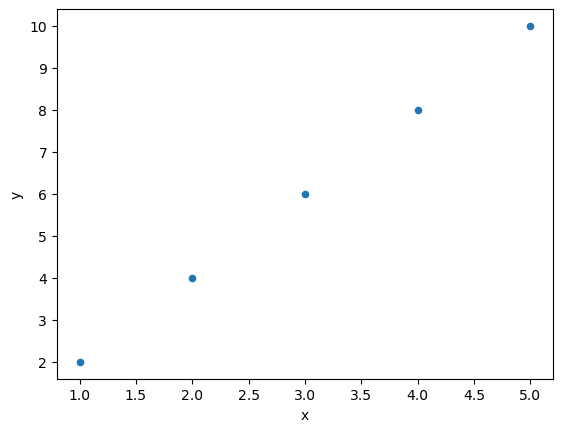

In [40]:
df.plot(x = 'x', y = 'y', kind = 'scatter')

Este código creará un gráfico de dispersión con los valores de 'x' en el eje horizontal y los valores de 'y' en el eje vertical.

Puedes personalizar tu gráfico utilizando los métodos de `Matplotlib`. Por ejemplo, para cambiar el color de los puntos, puedes utilizar el parámetro `color`:

<AxesSubplot:xlabel='x', ylabel='y'>

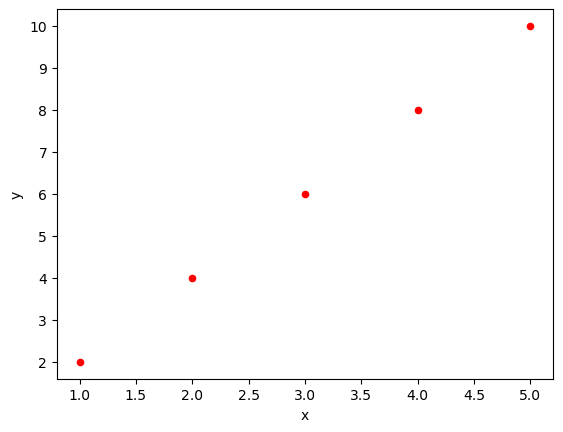

In [41]:
df.plot(x = 'x', y = 'y', kind = 'scatter', color = 'red')

La función `plot()` de Pandas es utilizada para visualizar datos de un DataFrame o Series. La sintaxis básica es la siguiente:

```python
DataFrame.plot(x = None, y = None, kind = 'line', ax = None, subplots = False, layout = None, figsize = None, use_index = True, title = None, grid = None, legend = True, style = None, logx = False, logy = False, loglog = False, xticks = None, yticks = None, xlim = None, ylim = None, rot = None, xerr = None, yerr = None, label = None, secondary_y = False, **kwds)
```
A continuación, te explico los principales parámetros de esta función:

- `x` y `y`: son las etiquetas o nombres de las columnas que se utilizarán para el eje x y el eje y, respectivamente.
- `kind`: es el tipo de gráfico que se quiere generar, como 'line' para un gráfico de líneas, 'bar' para un gráfico de barras, 'scatter' para un gráfico de dispersión, etc. Por defecto, el valor es 'line'.
- `figsize`: es un parámetro opcional que permite especificar el tamaño del gráfico en pulgadas. El valor por defecto es (6,4).
- `title`: es un parámetro opcional que permite agregar un título al gráfico.
- `xlabel` y `ylabel`: son parámetros opcionales que permiten agregar etiquetas a los ejes x e y del gráfico.
- `xlim` y `ylim`: son parámetros opcionales que permiten establecer los límites del eje x e y, respectivamente.
- `legend`: es un parámetro opcional que permite controlar si se muestra o no la leyenda en el gráfico. El valor por defecto es True.
- `style`: es un parámetro opcional que permite especificar el estilo de la línea o puntos en el gráfico.
- `logx`, `logy` y `loglog`: son parámetros opcionales que permiten mostrar los ejes en una escala logarítmica en lugar de lineal.
- `subplots`: es un parámetro opcional que permite generar un gráfico para cada columna de un DataFrame y presentarlos en un arreglo de subplots.

Hay muchos otros parámetros opcionales que se pueden utilizar con la función `plot()`. Te recomiendo revisar la [documentación oficial de Pandas para obtener más detalles sobre la función y sus parámetros](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html).

In [42]:
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes")

,Fecha,Número de accidentes
0,2016-01-01,28
1,2016-01-02,104
2,2016-01-03,90
3,2016-01-04,122
4,2016-01-05,48
...,...,...
361,2016-12-27,112
362,2016-12-28,94
363,2016-12-29,95
364,2016-12-30,86


<AxesSubplot:xlabel='Fecha'>

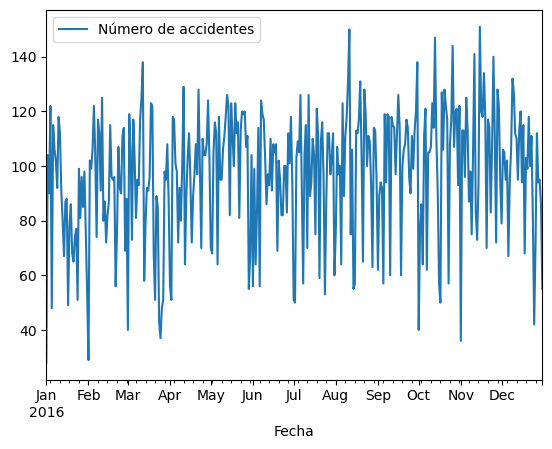

In [43]:
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line")

<AxesSubplot:xlabel='Fecha'>

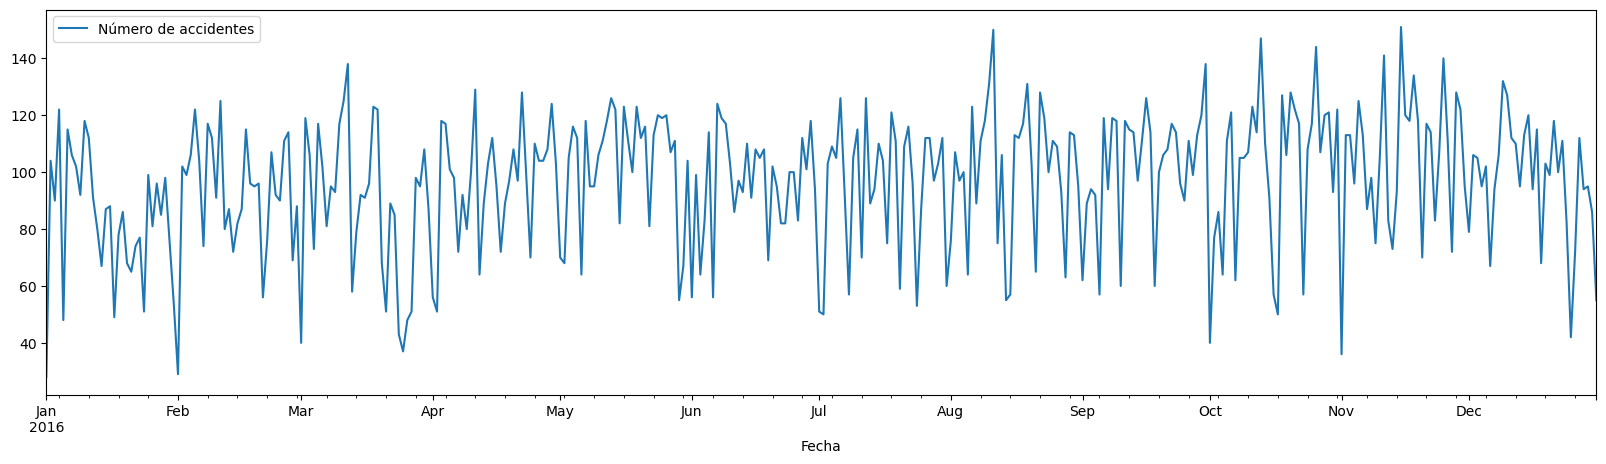

In [44]:
# Cambiemosle el tamaño al gráfico
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5))

<AxesSubplot:title={'center':'Accidentes diarios en Bogotá (2016)'}, xlabel='Fecha'>

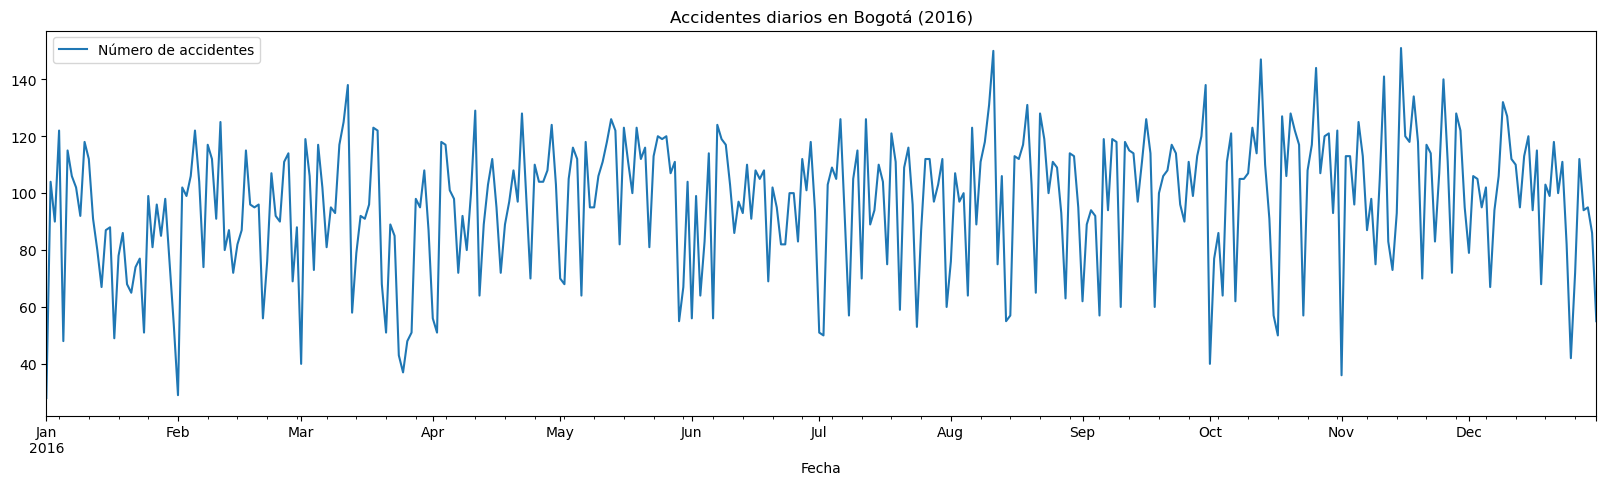

In [45]:
# Pongamosle título
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5), 
          title = "Accidentes diarios en Bogotá (2016)")

<AxesSubplot:title={'center':'Accidentes diarios en Bogotá (2016)'}, xlabel='Fecha'>

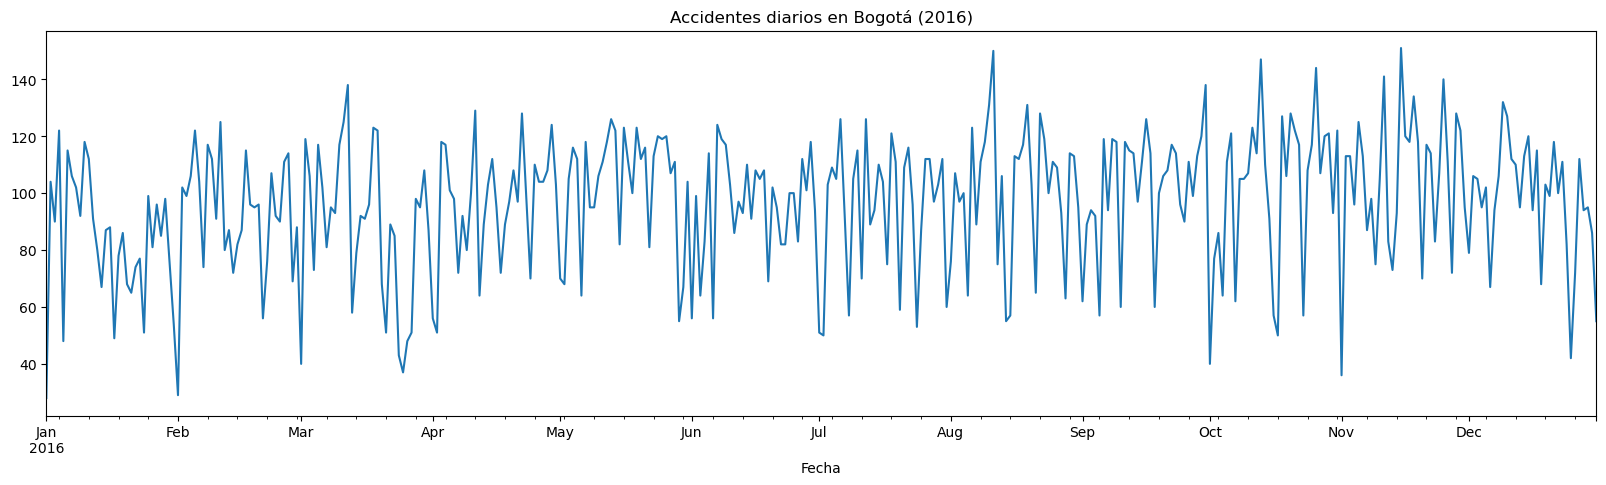

In [46]:
# Quitemosle la legenda
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5), 
          title = "Accidentes diarios en Bogotá (2016)", legend = False)

<AxesSubplot:title={'center':'Accidentes diarios en Bogotá (2016)'}, xlabel='Fecha'>

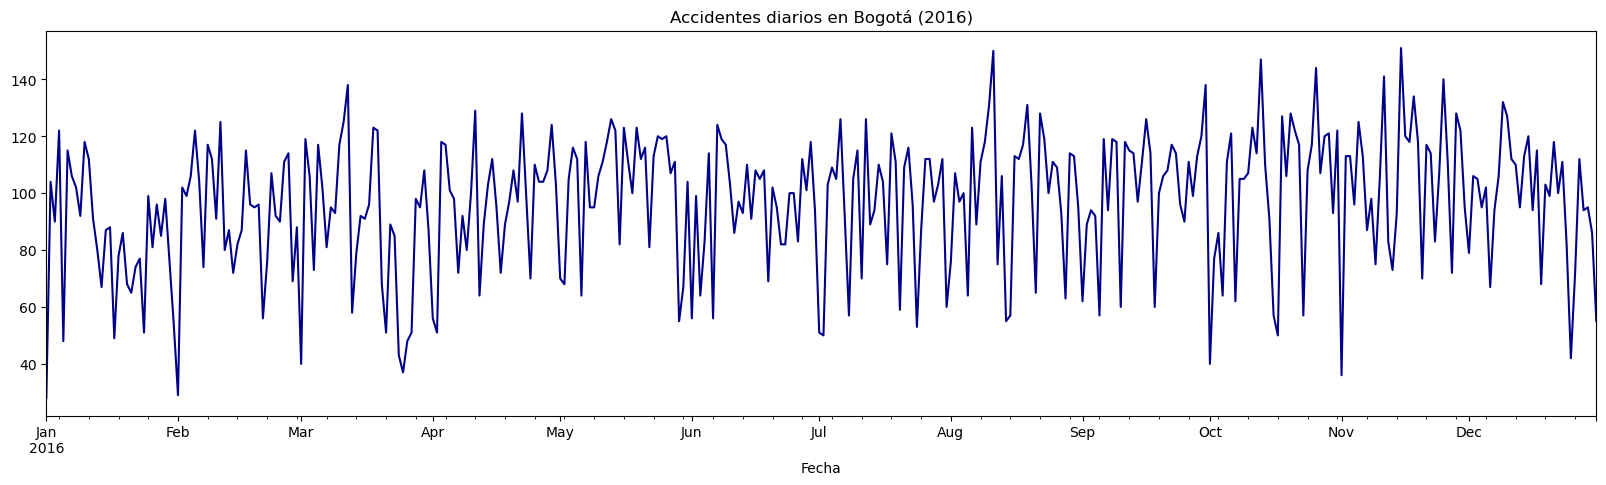

In [47]:
# Pongamosle color a la línea
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5), 
          title = "Accidentes diarios en Bogotá (2016)", legend = False,
          color = "darkblue")

¿Cómo hago para saber qué colores existen? Por defecto, `pandas` y `matplotlib` tienen algunas palabras asociadas a algunos [colores](https://matplotlib.org/stable/gallery/color/named_colors.html)

<center>
<div>
<img src="img/colors.png" width="400"/>
</div>
</center>

<AxesSubplot:title={'center':'Accidentes diarios en Bogotá (2016)'}, xlabel='Fecha'>

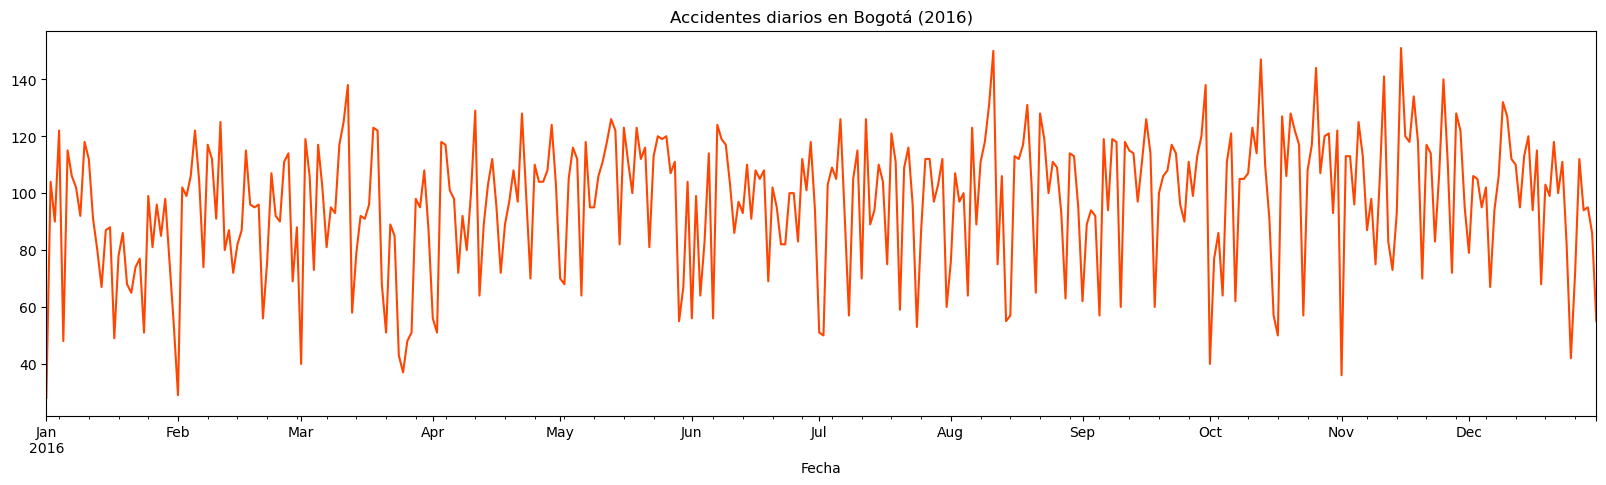

In [48]:
# Pongamosle color a la línea
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5), 
          title = "Accidentes diarios en Bogotá (2016)", legend = False,
          color = "orangered")

<AxesSubplot:title={'center':'Accidentes diarios en Bogotá (2016)'}, xlabel='Fecha'>

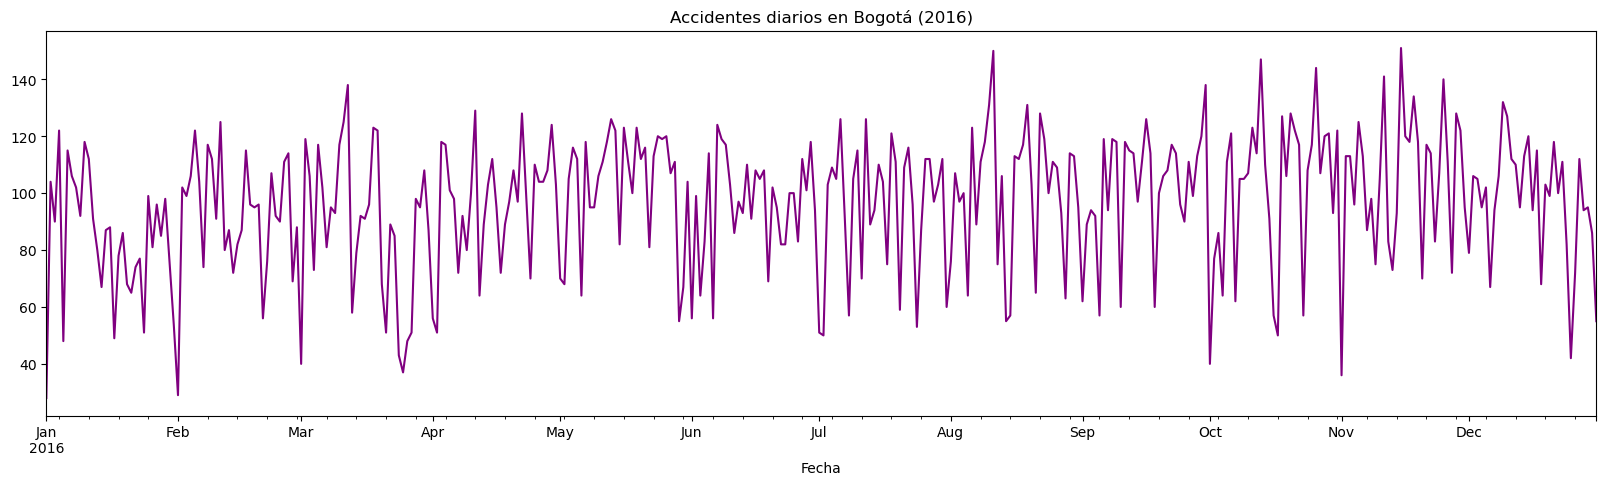

In [49]:
# Pongamosle color a la línea
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5), 
          title = "Accidentes diarios en Bogotá (2016)", legend = False,
          color = "purple")

<AxesSubplot:title={'center':'Accidentes diarios en Bogotá (2016)'}, xlabel='Fecha'>

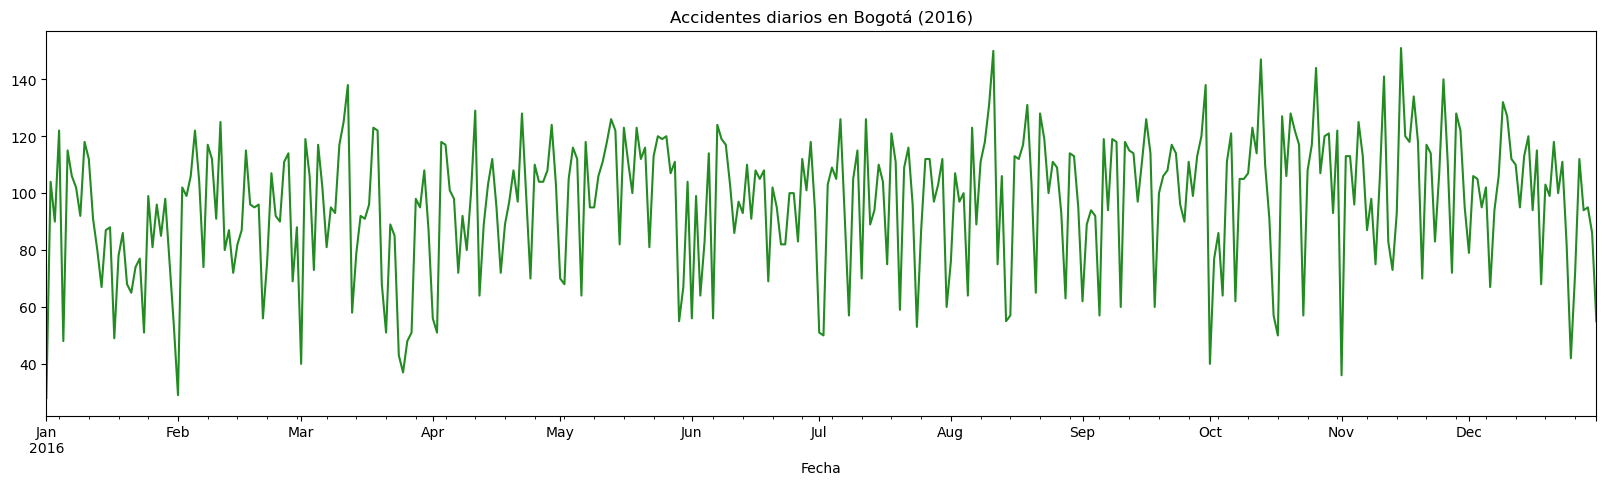

In [50]:
# Pongamosle color a la línea
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5), 
          title = "Accidentes diarios en Bogotá (2016)", legend = False,
          color = "forestgreen")

Sin embargo, puede crear cualquier color que quiera a partir del [código HEX](https://www.google.com/search?q=HEX+color&rlz=1C1CHZN_enCO1034CO1034&sxsrf=APwXEdfScUmp_Pr0bIhq9xV33av52uCWKA%3A1680729192725&ei=aOQtZOv1K--FwbkP1PCygAM&ved=0ahUKEwjryfuT1JP-AhXvQjABHVS4DDAQ4dUDCA8&uact=5&oq=HEX+color&gs_lcp=Cgxnd3Mtd2l6LXNlcnAQAzIHCAAQigUQQzIHCAAQigUQQzIHCAAQigUQQzIHCAAQigUQQzIGCAAQBxAeMgcIABCKBRBDMggIABCABBDLATIICAAQgAQQywEyBggAEAcQHjIGCAAQBxAeOgoIABBHENYEELADOgoIABCKBRCwAxBDSgQIQRgAUNYPWL0RYPYUaAJwAXgAgAHFAYgBlQSSAQMwLjOYAQCgAQHIAQrAAQE&sclient=gws-wiz-serp)


<center>
<div>
<img src="img/HEX.png" width="400"/>
</div>
</center>

<AxesSubplot:title={'center':'Accidentes diarios en Bogotá (2016)'}, xlabel='Fecha'>

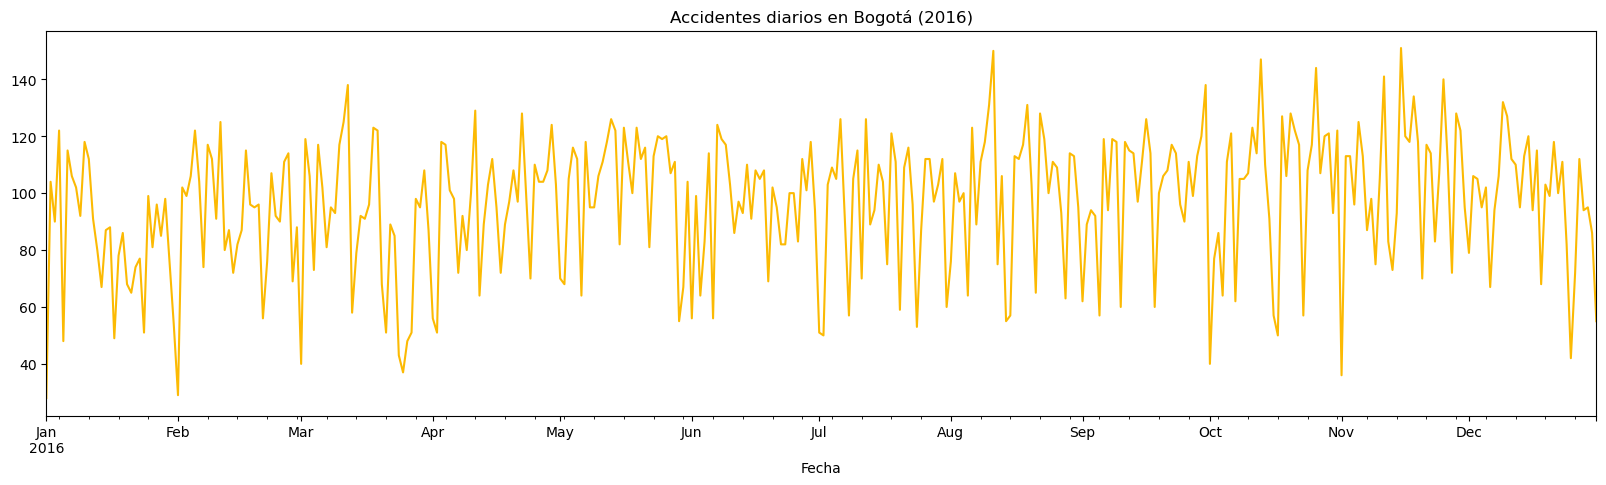

In [51]:
# Pongamosle color a la línea
accidentes.groupby("Fecha").size().reset_index(name = "Número de accidentes") \
    .plot(x = "Fecha", y = "Número de accidentes", kind = "line", figsize = (20, 5),
          title = "Accidentes diarios en Bogotá (2016)", legend = False,
          color = "#fcba03")

Exploremos otro tipo de gráficos como los histogramas. Veamos cómo se distribuyen la cantidad de accidentes por horas del día

<AxesSubplot:ylabel='Frequency'>

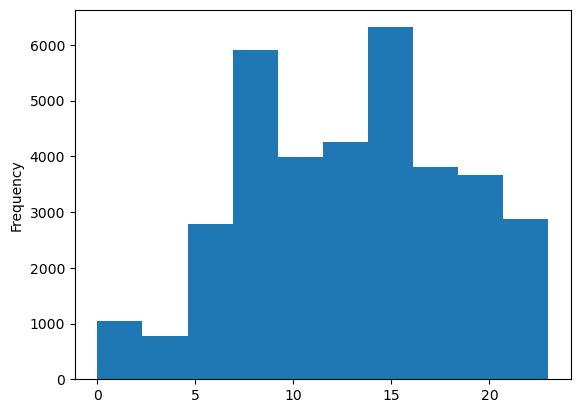

In [52]:
# Hay dos picos de accidentalidad: Al rededor de las 7-8 am y 2-3 pm
accidentes["HoraOcurrencia"].dt.hour.plot(kind = "hist")

<AxesSubplot:title={'center':'Distribución de los accidentes por hora del día'}, ylabel='Frequency'>

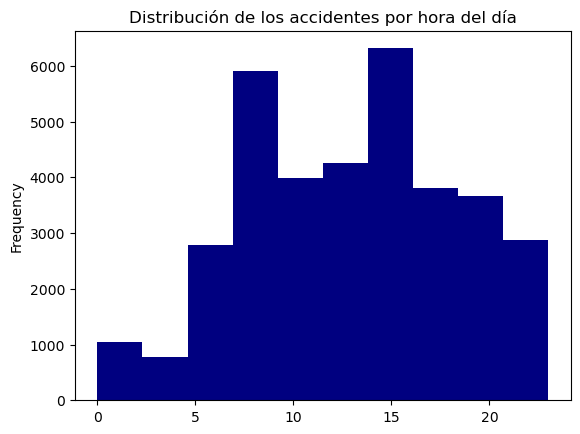

In [53]:
accidentes["HoraOcurrencia"].dt.hour.plot(kind = "hist", color = "navy", 
                                          title = "Distribución de los accidentes por hora del día")

<AxesSubplot:title={'center':'Relación entre heridos y muertos'}, xlabel='Número de muertos', ylabel='Número de heridos'>

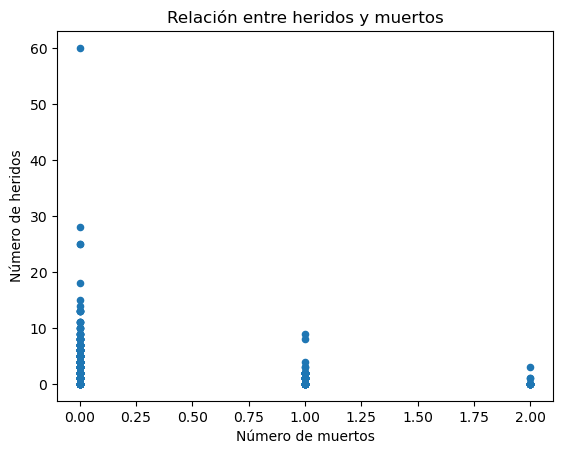

In [54]:
accidentes.plot(x = "TotalMuertos", y = "TotalHeridos", kind = "scatter", 
                xlabel = "Número de muertos", ylabel = "Número de heridos",
                title = "Relación entre heridos y muertos")

In [80]:
# Creemos un gráfico de barras en donde se visualice la cantidad de accidentes por tipo
tipos_accidentes = accidentes["GravedadNombre"].value_counts().reset_index()
tipos_accidentes

,index,GravedadNombre
0,Solo Daños,24209
1,Con Heridos,10654
2,Con Muertos,560


<AxesSubplot:title={'center':'Cantidad de accidentes por tipo'}, xlabel='Tipo de accidente', ylabel='Cantidad'>

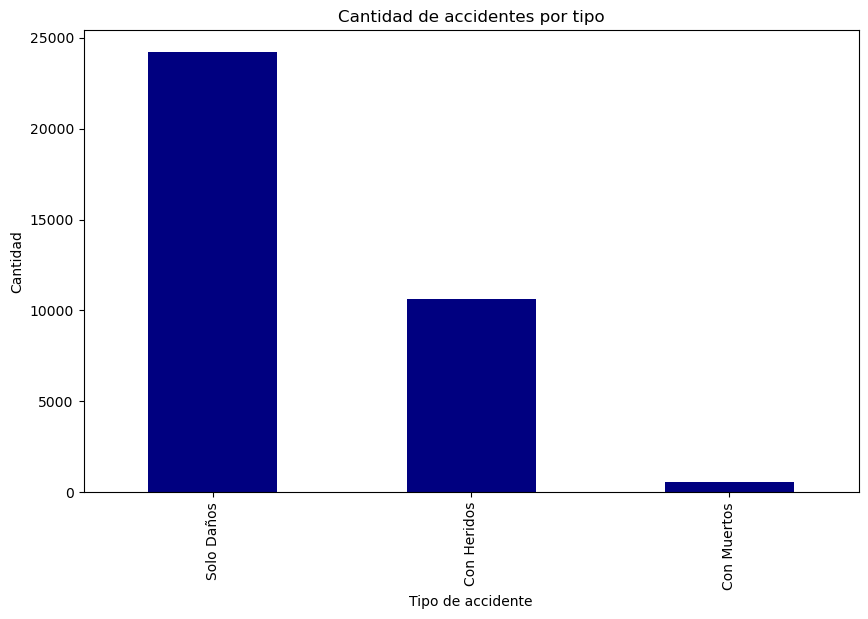

In [66]:
tipos_accidentes.plot(x = "index", y = "GravedadNombre", kind = "bar", 
                      xlabel = "Tipo de accidente", ylabel = "Cantidad", 
                      color = "navy", legend = False, 
                      title = "Cantidad de accidentes por tipo",
                      figsize = (10, 6))

In [81]:
# ¿Cómo pasamos estos números a porcentajes?
tipos_accidentes["Proporción"] = tipos_accidentes["GravedadNombre"]/tipos_accidentes["GravedadNombre"].sum()

<AxesSubplot:ylabel='Proporción'>

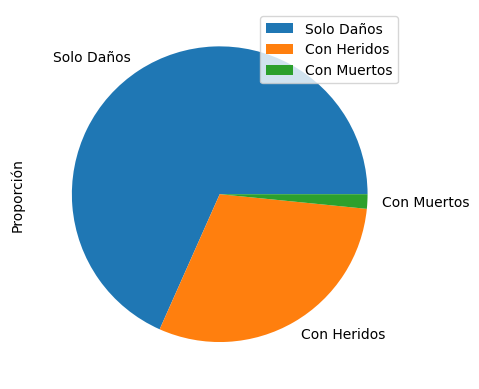

In [85]:
# Si vamos a hacer un gráfico de torta el índice debe reflejar las categoría a visualizar
tipos_accidentes.set_index("index").plot(y = "Proporción", kind = "pie")

Esos colores están HORRIBLES. Busquemos alguna paleta en mi página favorita: [coolors](https://coolors.co/)

<center>
<div>
<img src="img/coolors.png" width="800"/>
</div>
</center>

<AxesSubplot:ylabel='Proporción'>

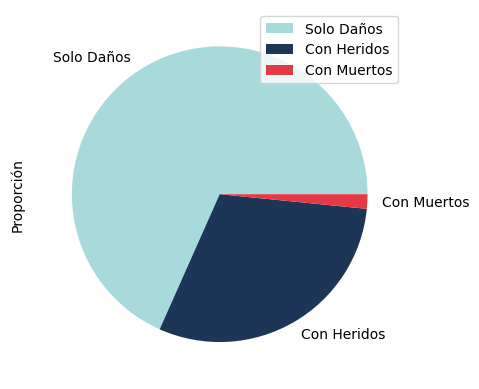

In [93]:
tipos_accidentes.set_index("index").plot(y = "Proporción", kind = "pie", 
                                         colors = ["#a8dadc", "#1d3557", "#e63946"])

También podemos importar [paletas usando el paquete seaborn](https://seaborn.pydata.org/tutorial/color_palettes.html)

<center>
<div>
<img src="img/palette.png" width="800"/>
</div>
</center>

In [111]:
import seaborn as sns
sns.color_palette("Spectral")

[(0.8853517877739331, 0.3190311418685121, 0.29042675893886966),
 (0.9873125720876587, 0.6473663975394078, 0.3642445213379469),
 (0.9971549404075356, 0.9118031526336025, 0.6010765090349866),
 (0.9288735101883892, 0.9715494040753557, 0.6380622837370243),
 (0.6334486735870821, 0.8521337946943485, 0.6436755094194541),
 (0.2800461361014994, 0.6269896193771626, 0.7024221453287197)]

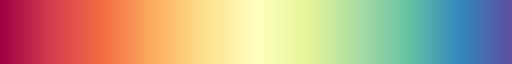

In [112]:
sns.color_palette("Spectral", as_cmap = True)

In [115]:
sns.color_palette("Paired")

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

In [116]:
sns.color_palette("Blues")

[(0.8584083044982699, 0.9134486735870818, 0.9645674740484429),
 (0.7309496347558632, 0.8394771241830065, 0.9213225682429834),
 (0.5356862745098039, 0.746082276047674, 0.8642522106881968),
 (0.32628988850442137, 0.6186236063052672, 0.802798923490965),
 (0.16696655132641292, 0.48069204152249134, 0.7291503267973857),
 (0.044059976931949255, 0.3338869665513264, 0.6244521337946944)]

In [117]:
sns.color_palette("viridis")

[(0.275191, 0.194905, 0.496005),
 (0.212395, 0.359683, 0.55171),
 (0.153364, 0.497, 0.557724),
 (0.122312, 0.633153, 0.530398),
 (0.288921, 0.758394, 0.428426),
 (0.626579, 0.854645, 0.223353)]

In [119]:
sns.color_palette('RdYlGn')

[(0.8899653979238754, 0.2867358708189158, 0.19815455594002307),
 (0.9873125720876587, 0.6473663975394078, 0.3642445213379469),
 (0.9971549404075356, 0.9118031526336025, 0.6010765090349866),
 (0.8918877354863515, 0.954479046520569, 0.6010765090349867),
 (0.6165321030372937, 0.8359092656670513, 0.41191849288735105),
 (0.22468281430219145, 0.6558246828143022, 0.3444059976931949)]

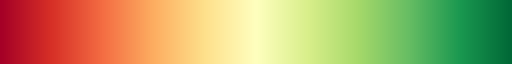

In [120]:
sns.color_palette('RdYlGn', as_cmap = True)

In [122]:
sns.color_palette('RdYlGn_r')

[(0.2246828143021916, 0.6558246828143023, 0.34440599769319497),
 (0.6165321030372936, 0.8359092656670511, 0.41191849288735105),
 (0.8918877354863515, 0.954479046520569, 0.6010765090349867),
 (0.9971549404075356, 0.9118031526336025, 0.6010765090349866),
 (0.9873125720876587, 0.647366397539408, 0.36424452133794694),
 (0.8899653979238754, 0.28673587081891583, 0.19815455594002307)]

<AxesSubplot:ylabel='Proporción'>

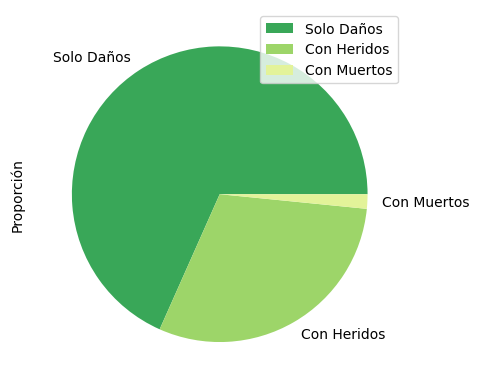

In [126]:
tipos_accidentes.set_index("index").plot(y = "Proporción", kind = "pie", 
                                         colors = sns.color_palette('RdYlGn_r'))

<AxesSubplot:ylabel='Proporción'>

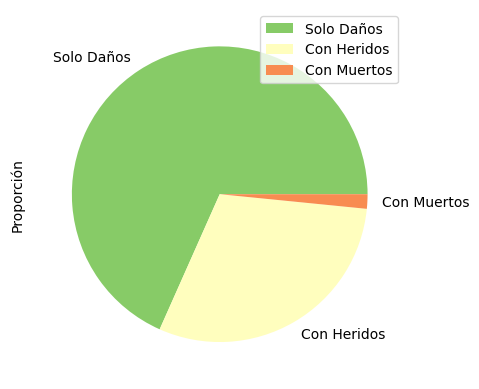

In [132]:
tipos_accidentes.set_index("index").plot(y = "Proporción", kind = "pie", 
                                         colors = sns.color_palette('RdYlGn_r', n_colors = 3))

<AxesSubplot:title={'center':'Gravedad de los accidentes'}>

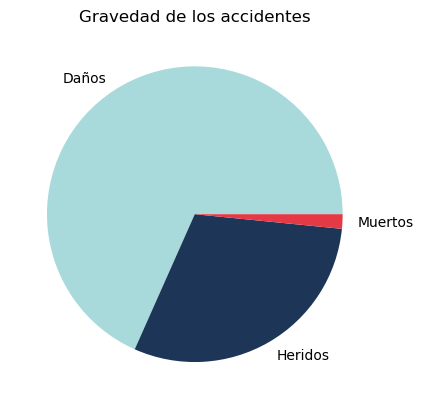

In [133]:
# También se pueden poner los labels de forma manual en vez de usar el índice
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes",
                      legend = False)

<AxesSubplot:title={'center':'Gravedad de los accidentes'}>

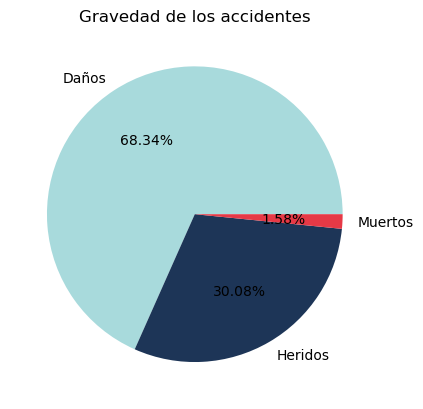

In [134]:
# Podemos añadirle los porcentajes
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes",
                      legend = False,
                      autopct = '%1.2f%%',)

<AxesSubplot:title={'center':'Gravedad de los accidentes'}>

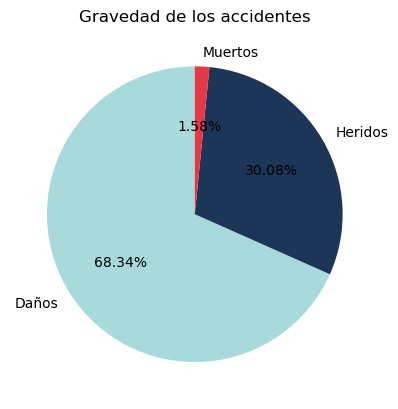

In [137]:
# Podemos mover el pie
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes",
                      legend = False,
                      autopct = '%1.2f%%',
                      startangle = 90)

<AxesSubplot:title={'center':'Gravedad de los accidentes'}>

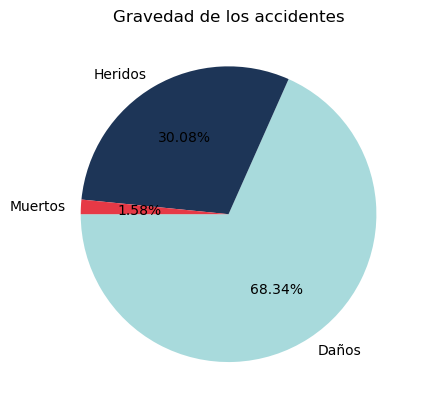

In [141]:
# Podemos mover el pie
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes",
                      legend = False,
                      autopct = '%1.2f%%',
                      startangle = 180)

<AxesSubplot:title={'center':'Gravedad de los accidentes'}>

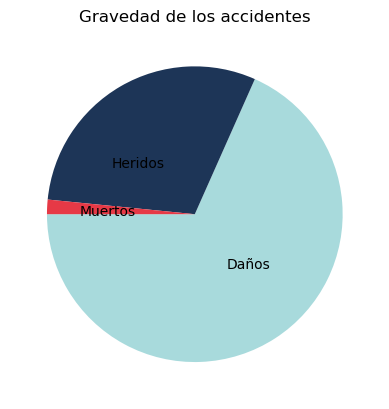

In [144]:
# Podemos mover la legenda
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes",
                      legend = False,
                      startangle = 180,
                      # Distancia de los labels al centro
                      labeldistance = 0.4)

<AxesSubplot:title={'center':'Gravedad de los accidentes'}>

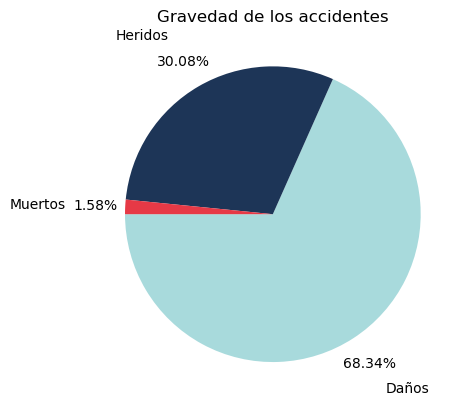

In [159]:
# Podemos mover los porcentajes
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes",
                      legend = False,
                      startangle = 180,
                      # Distancia de los labels al centro
                      labeldistance = 1.4,
                      # Distancia de los porcentajes al centro
                      autopct = '%1.2f%%',
                      pctdistance = 1.2
                      )

<AxesSubplot:title={'center':'Gravedad de los accidentes'}>

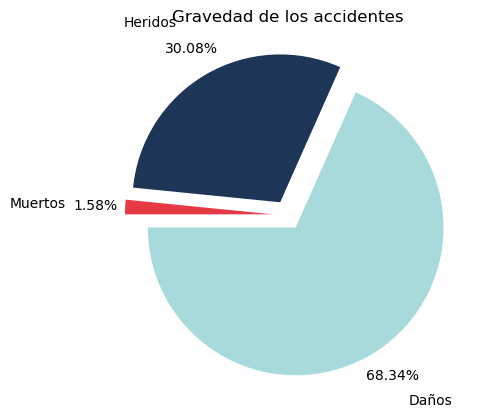

In [161]:
# Separar las porciones
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes",
                      legend = False,
                      startangle = 180,
                      # Distancia de los labels al centro
                      labeldistance = 1.4,
                      # Distancia de los porcentajes al centro
                      autopct = '%1.2f%%',
                      pctdistance = 1.2,
                      # Mover porciones
                      explode = [0.1, 0.1, 0.1]
                      )

<AxesSubplot:title={'center':'Gravedad de los accidentes \n\n'}>

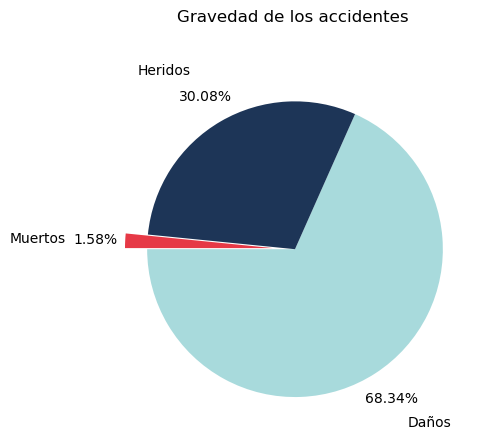

In [172]:
# Resaltar una porción
tipos_accidentes.plot(y = "Proporción", 
                      labels = ["Daños", "Heridos", "Muertos"], 
                      kind = "pie", 
                      colors = ["#a8dadc", "#1d3557", "#e63946"],
                      ylabel = "",
                      title = "Gravedad de los accidentes \n\n",
                      legend = False,
                      startangle = 180,
                      # Distancia de los labels al centro
                      labeldistance = 1.4,
                      # Distancia de los porcentajes al centro
                      autopct = '%1.2f%%',
                      pctdistance = 1.2,
                      # Mover porciones
                      explode = [0, 0, 0.15]
                      )

## Ejercicios
Vamos a utilizar un conjunto de bases de datos de la tienda brasileña de comercio electrónico Olist. Los datos tienen información de alrededor de 100 mil pedidos entre 2016 y 2018 y dependiendo de la base podrá ver diferentes dimensiones de cada pedido como el estado, el precio, el pago, el rendimiento del flete, la ubicación del cliente, los atributos del producto, las reseñas escritas por los clientes, etc. Notará además que algunos datos tienen una geolocalización que relaciona los códigos postales brasileños con las coordenadas latitud/longitud.

Los datos que manipulará a continuación son datos comerciales reales, sin embargo se han anonimizado y las referencias a las empresas y socios en el texto de revisión se han reemplazado con los nombres de las grandes casas de Game of Thrones.

El esquema de los datos se presenta en la siguiente figura: 
<center>
<div>
<img src="img/diagrama_bases.png" width="800"/>
</div>
</center>

Para más información puede visitar la siguiente [competencia de Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

Luego de entender el esquema de datos, el primer paso es importar e inspeccionar someramente las siguientes bases de datos:
1. Importe la base de datos `olist_customers_dataset.csv` para obtener los directorios de clientes.
2. Importe la base de datos `olist_geolocation_dataset.csv` para obtener la información espacial de [Brasil](https://es.wikipedia.org/wiki/Geograf%C3%ADa_de_Brasil#/media/Archivo:Brasil_administrative_map_ES.png).
3. Importe la base de datos `olist_order_payments_dataset.csv` para obtener información sobre los pagos.
4. Importe la base de datos `olist_order_items_dataset.csv` para obtener la información de los productos vendidos.
5. Importe la base de datos `olist_products_dataset.csv` para obtener información de los productos.
6. Importe la base de datos `olist_sellers_dataset.csv` para obtener la información de los vendedores.
7. Importe la base de datos `olist_orders_dataset.csv` para obtener información de las entregas.
8. Importe la base de datos `product_category_name_translation.csv` para traducir a inglés los tipos de productos

In [182]:
clientes = pd.read_csv('olist_customers_dataset.csv')
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [183]:
clientes.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [184]:
geo_brasil = pd.read_csv('olist_geolocation_dataset.csv')
geo_brasil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [185]:
geo_brasil.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [186]:
pagos = pd.read_csv('olist_order_payments_dataset.csv' )
pagos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [187]:
pagos.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [188]:
ventas = pd.read_csv('olist_order_items_dataset.csv' )
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [189]:
ventas.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [190]:
productos = pd.read_csv('olist_products_dataset.csv' )
productos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [191]:
productos.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [193]:
vendedores = pd.read_csv('olist_sellers_dataset.csv' )
vendedores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [194]:
vendedores.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [195]:
entregas = pd.read_csv('olist_orders_dataset.csv' )
entregas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [196]:
entregas.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [197]:
traduccion = pd.read_csv('product_category_name_translation.csv')
traduccion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [198]:
traduccion.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### Estadísticas Descriptivas Nivel I
1. ¿Qué bases se pueden pegar directamente? No debe realizar el pegue, solo debe escribir su respuesta.

A partir del esquema de los datos se pueden identificar que las llaves para pegar los datos son: `order_id`, `customer_id`, `product_id`, `zip_code_prefix` y `seller_id`. En ese orden de ideas, los pegues que se pueden hacer según la llave serían:

1. Las bases que se pueden relacionar directamente a partir de `order_id` son:
- `olist_order_reviews_dataset`
- `olist_orders_dataset`
- `olist_orders_payment_dataset`
- `olist_order_items_dataset`
2. Las bases que se pueden relacionar directamente a partir de `customer_id` son:
- `olist_orders_dataset`
- `olist_order_customer_dataset`
3. Las bases que se pueden relacionar directamente a partir de `product_id` son:
- `olist_products_dataset`
- `olist_order_items_dataset`
4. Las bases que se pueden relacionar directamente a partir de `zip_code_prefix` son:
- `olist_order_customer_dataset`
- `olist_geolocation_dataset`
- `olist_sellers_dataset`
5. Las bases que se pueden relacionar directamente a partir de `seller_id` son:
- `olist_order_items_dataset`
- `olist_sellers_dataset`

2. ¿Cuál fue el producto más vendido? ¿Qué tipo de producto es (en inglés)?

In [207]:
# El producto más vendido
mas_vendido = ventas["product_id"].value_counts().index[0]
mas_vendido

'aca2eb7d00ea1a7b8ebd4e68314663af'

In [215]:
# ¿Cuál es la categoría de dicho producto?
categoria = productos.loc[productos.product_id == mas_vendido, "product_category_name"].values[0]
categoria

'moveis_decoracao'

In [218]:
# ¿Cuál es el nombre del producto en inglés?
traduccion.loc[traduccion.product_category_name == categoria, "product_category_name_english"].values[0]

'furniture_decor'

3. Pegue a la tabla de productos con la de traducción.

In [223]:
productos2 = productos.merge(traduccion, how = "left", on = "product_category_name")
productos.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [224]:
productos2.isna().sum()

product_id                         0
product_category_name            610
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   2
product_length_cm                  2
product_height_cm                  2
product_width_cm                   2
product_category_name_english    623
dtype: int64

4. ¿Cuánto se gastó en promedio por compra?

In [230]:
# En promedio se gastó 120 reales
ventas["price"].mean()

120.65373901477311

5. ¿Cómo se distribuyo el tipo de pago? 

In [239]:
tipo_pago = pagos["payment_type"].value_counts().reset_index()
tipo_pago 

,index,payment_type
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


<AxesSubplot:xlabel='Tipo de pago', ylabel='Cantidad'>

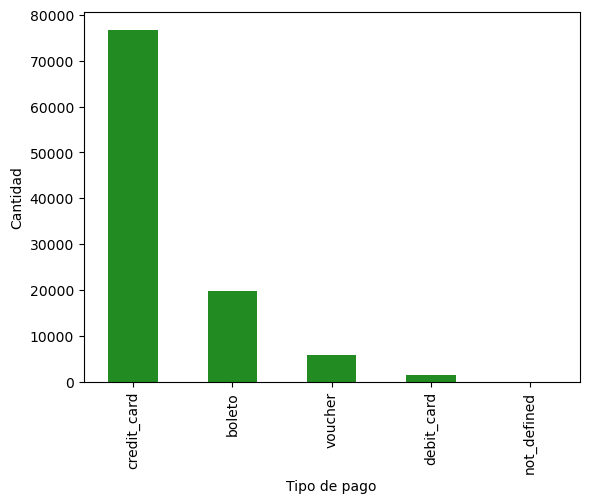

In [243]:
tipo_pago.plot(x = "index", y = "payment_type", kind = "bar", 
               xlabel = "Tipo de pago", ylabel = "Cantidad", 
               legend = False, color = "forestgreen")

In [271]:
tipo_pago

,index,payment_type
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


<AxesSubplot:>

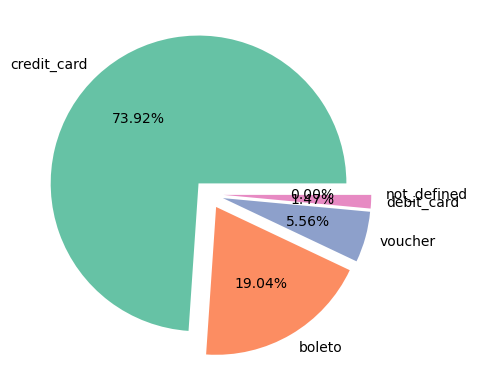

In [288]:
tipo_pago.plot(labels = tipo_pago["index"].values, y = "payment_type", kind = "pie", 
               legend = False, autopct = "%1.2f%%", 
               ylabel = "", 
               colors = sns.color_palette("Set2"),
               explode = [0.1, 0.1, 0.1, 0.1, 0.1])

6. ¿Cuánto se gastó en promedio por tipo de producto? 

In [299]:
ventas2 = ventas.merge(productos2, how = "left", on = 'product_id')
precio_promedio = ventas2.groupby('product_category_name_english')['price'].mean().reset_index() \
    .sort_values("price", ascending = False)

<AxesSubplot:xlabel='product_category_name_english'>

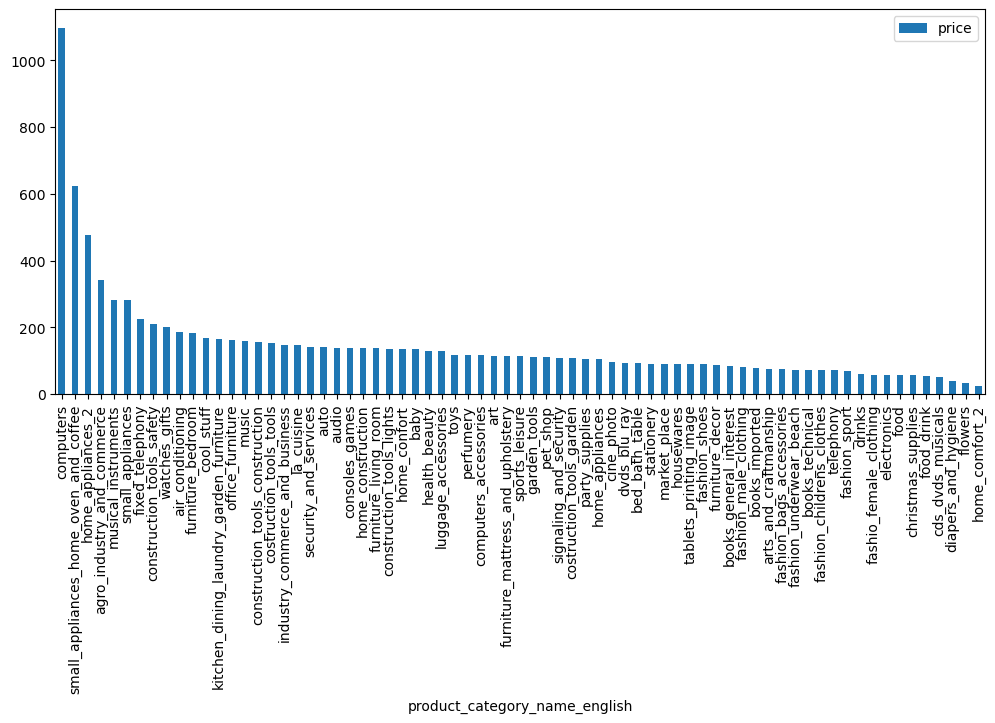

In [388]:
precio_promedio.plot(x = "product_category_name_english", y = "price", kind = "bar",
                     figsize = (12, 5))

¿Cómo funciona `plt.subplots()`?

En la línea de código `fig, ax = plt.subplots()`, `fig` y `ax` son dos variables que se utilizan para almacenar los objetos de figura y ejes devueltos por la función `plt.subplots()`, respectivamente.

La variable `fig` almacena el objeto de figura que representa toda la ventana o lienzo de la gráfica, mientras que la variable `ax` almacena el objeto de ejes que representa una región rectangular dentro de la `figura donde los gráficos se trazan.

Es importante tener en cuenta que la función `plt.subplots()` devuelve dos valores, una figura y un arreglo de ejes. El arreglo de ejes es una matriz de objetos de ejes, y su tamaño está determinado por el número de filas y columnas especificados como argumentos en la función `plt.subplots()`. Si no se especifican estos argumentos, se utiliza un valor predeterminado de una sola fila y una sola columna.

Una vez que se han almacenado los objetos de figura y ejes en las variables `fig` y `ax`, respectivamente, podemos usarlos para personalizar la figura y agregar diferentes tipos de gráficos en el conjunto de ejes. Por ejemplo, podemos cambiar el tamaño de la figura, agregar títulos y etiquetas de eje, cambiar los colores y estilos de las líneas, y mucho más.

In [356]:
import matplotlib.pyplot as plt
import numpy as np

In [357]:
# Generar algunos datos de ejemplo
x = np.linspace(0, 2*np.pi, 100)
x

array([0.        , 0.06346652, 0.12693304, 0.19039955, 0.25386607,
       0.31733259, 0.38079911, 0.44426563, 0.50773215, 0.57119866,
       0.63466518, 0.6981317 , 0.76159822, 0.82506474, 0.88853126,
       0.95199777, 1.01546429, 1.07893081, 1.14239733, 1.20586385,
       1.26933037, 1.33279688, 1.3962634 , 1.45972992, 1.52319644,
       1.58666296, 1.65012947, 1.71359599, 1.77706251, 1.84052903,
       1.90399555, 1.96746207, 2.03092858, 2.0943951 , 2.15786162,
       2.22132814, 2.28479466, 2.34826118, 2.41172769, 2.47519421,
       2.53866073, 2.60212725, 2.66559377, 2.72906028, 2.7925268 ,
       2.85599332, 2.91945984, 2.98292636, 3.04639288, 3.10985939,
       3.17332591, 3.23679243, 3.30025895, 3.36372547, 3.42719199,
       3.4906585 , 3.55412502, 3.61759154, 3.68105806, 3.74452458,
       3.8079911 , 3.87145761, 3.93492413, 3.99839065, 4.06185717,
       4.12532369, 4.1887902 , 4.25225672, 4.31572324, 4.37918976,
       4.44265628, 4.5061228 , 4.56958931, 4.63305583, 4.69652

In [363]:
y1 = np.sin(x)
y2 = np.cos(x)

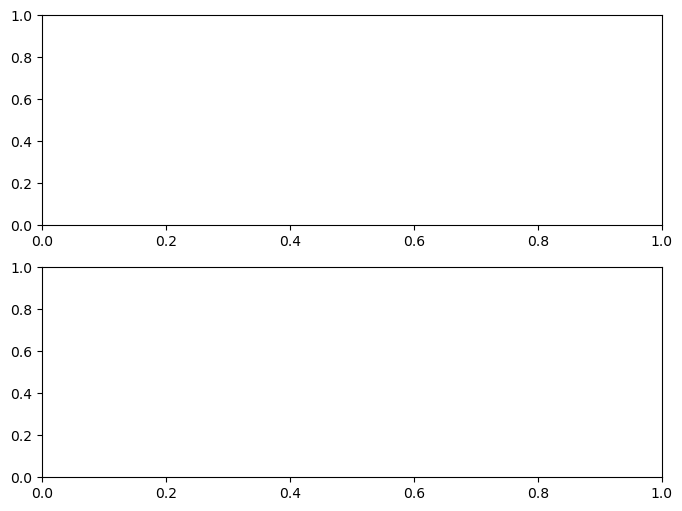

In [371]:
# Crear una figura y dos conjuntos de ejes
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (8, 6))

In [375]:
# Graficar la función seno en el primer conjunto de ejes
ax[0].plot(x, y1, color = 'blue', label = 'Seno')
ax[0].set_title('Conjunto de ejes 1')
ax[0].legend()

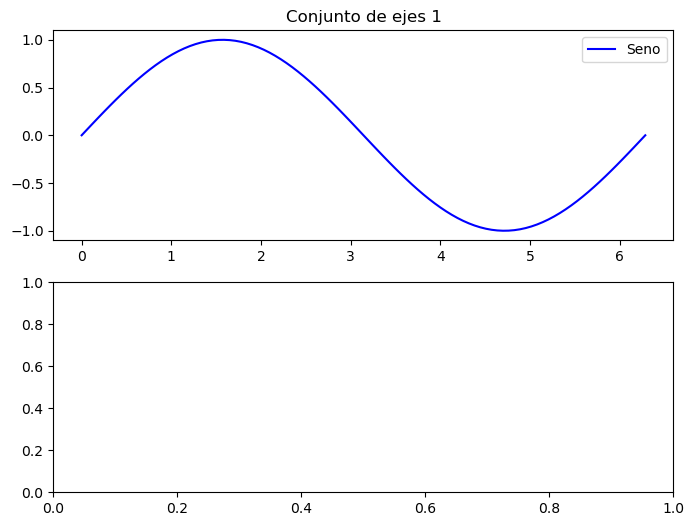

In [373]:
fig

In [376]:
# Graficar la función coseno en el segundo conjunto de ejes
ax[1].plot(x, y2, color = 'red', label=  'Coseno')
ax[1].set_title('Conjunto de ejes 2')
ax[1].legend()

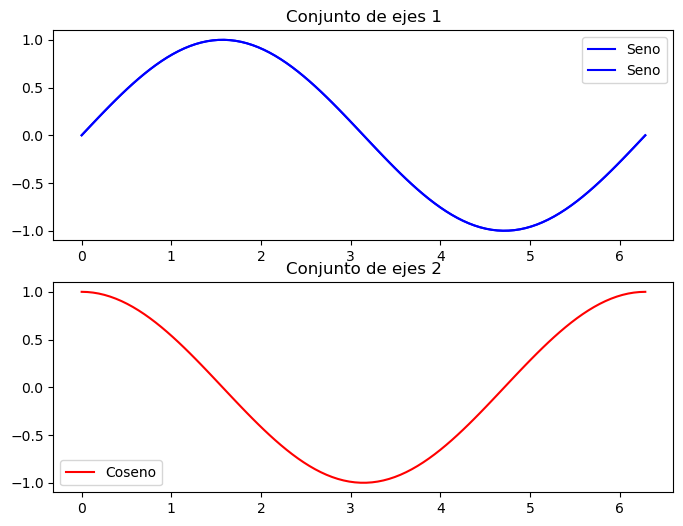

In [377]:
fig

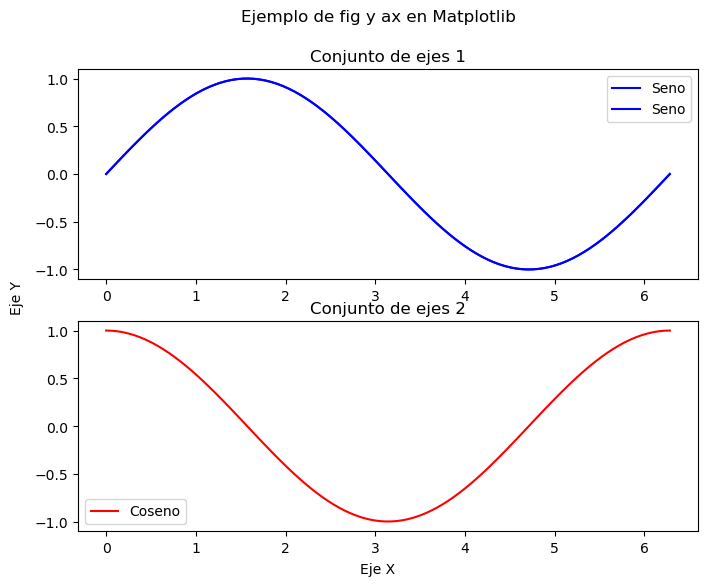

In [378]:
# Agregar título y etiquetas de eje a la figura
fig.suptitle('Ejemplo de fig y ax en Matplotlib')
fig.text(0.5, 0.04, 'Eje X', ha = 'center')
fig.text(0.04, 0.5, 'Eje Y', va = 'center', rotation = 'vertical')

# Mostrar la figura
fig

Text(0.5, 1.0, 'Precio promedio por categoría')

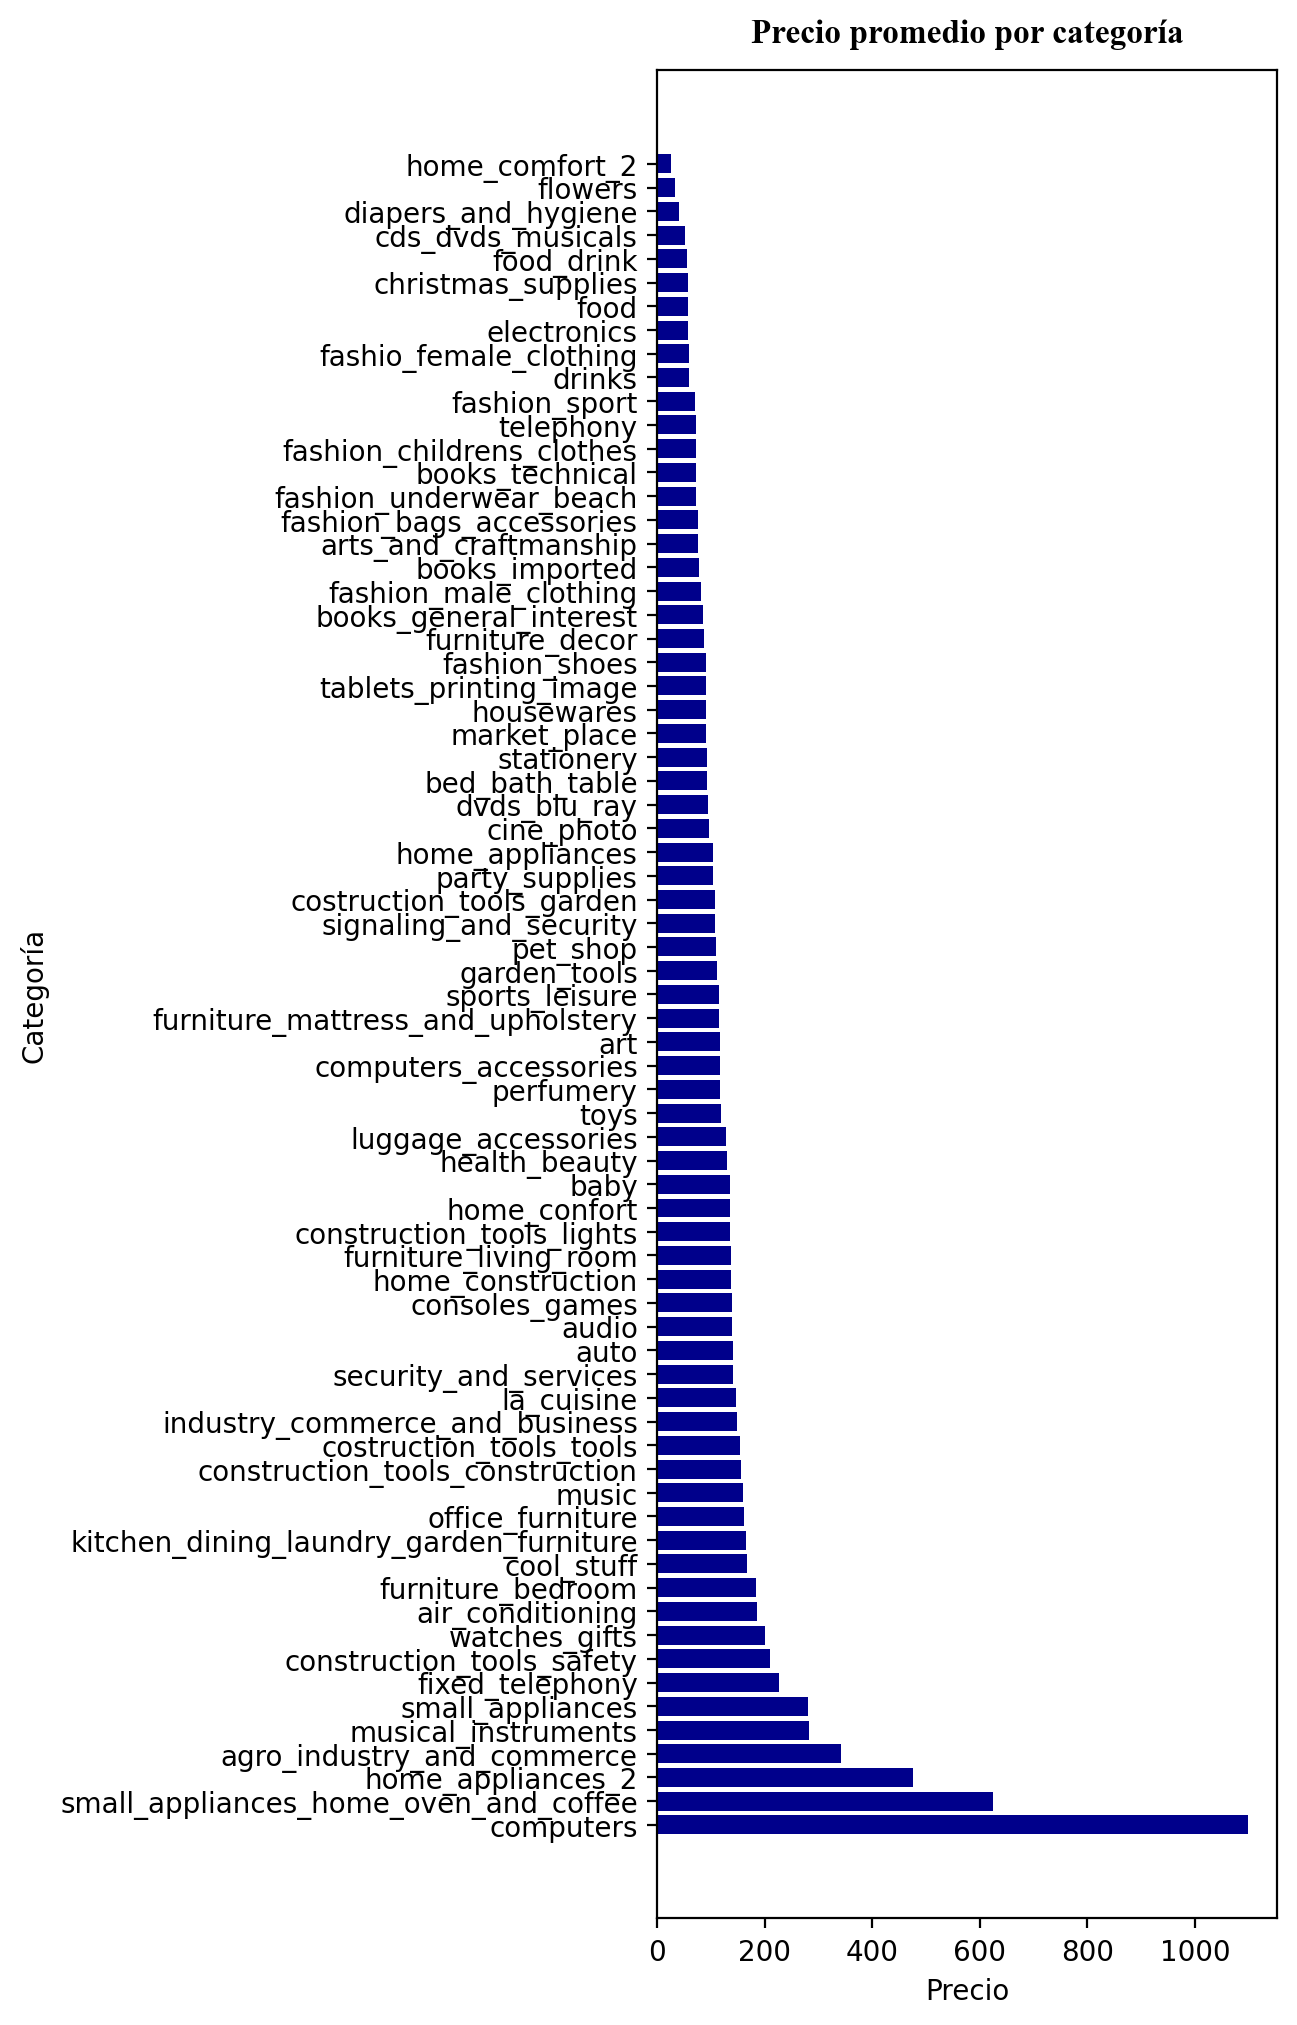

In [386]:
fig, ax = plt.subplots(figsize = (4, 12), dpi = 200)
ax.barh(width = precio_promedio["price"], y = precio_promedio["product_category_name_english"], color = "darkblue")
ax.set_xlabel("Precio") # plt.xlabel("Precio")
ax.set_ylabel("Categoría") # plt.ylabel("Categoría")
ax.set_title("Precio promedio por categoría", fontsize = 12, pad = 10, 
             fontname = "Times New Roman", fontweight = "bold") # plt.title()

7. ¿Cómo se distribuye el volumen de ventas por tipo de producto?

In [332]:
# Cantidad de ventas por productos
cantidades_productos = ventas2.groupby('product_category_name_english').size().reset_index(name = "Cantidad")
cantidades_productos = cantidades_productos.sort_values("Cantidad", ascending = False)

Text(0.5, 1.0, 'Número de productos vendidos por categoría')

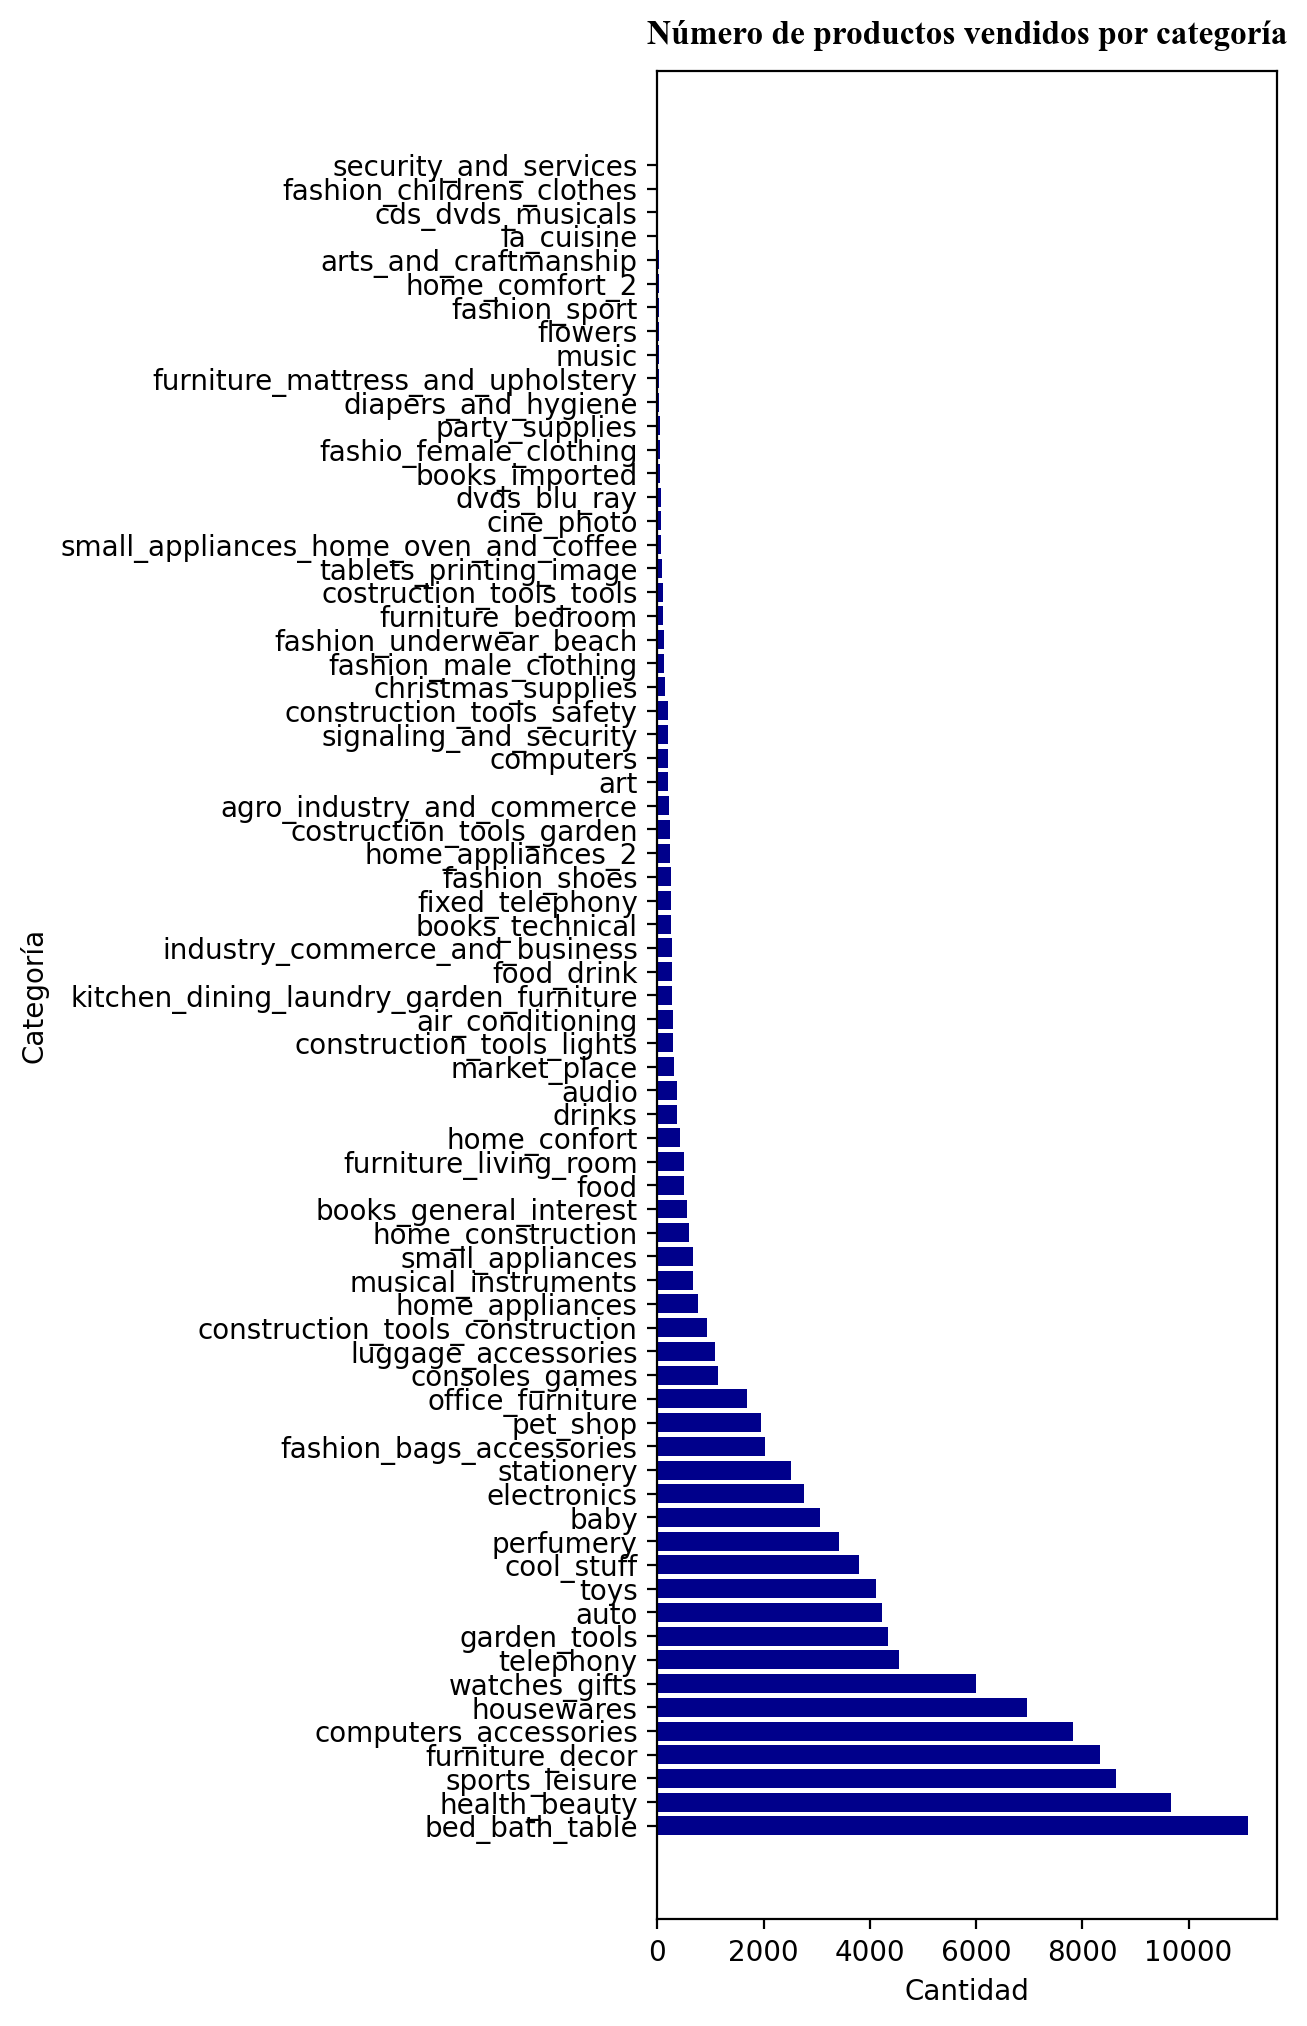

In [390]:
fig, ax = plt.subplots(figsize = (4, 12), dpi = 200)
ax.barh(width = cantidades_productos["Cantidad"], y = cantidades_productos["product_category_name_english"], 
        color = "darkblue")
plt.xlabel("Cantidad")
plt.ylabel("Categoría")
plt.title("Número de productos vendidos por categoría", fontsize = 12, pad = 10, 
          fontname = "Times New Roman", fontweight = "bold")

8. Construya la serie de tiempo de las ventas diarias

In [392]:
ventas3 = ventas2.merge(entregas, on = 'order_id', how = "left")

In [398]:
# Creamos la variable fecha de compra
ventas3["order_purchase_timestamp"] = pd.to_datetime(ventas3["order_purchase_timestamp"]) 
ventas3["order_purchase_timestamp"].head()

0   2017-09-13 08:59:02
1   2017-04-26 10:53:06
2   2018-01-14 14:33:31
3   2018-08-08 10:00:35
4   2017-02-04 13:57:51
Name: order_purchase_timestamp, dtype: datetime64[ns]

In [399]:
ventas3["fechas_compra"] = ventas3["order_purchase_timestamp"].dt.date
ventas3["fechas_compra"].head()

0    2017-09-13
1    2017-04-26
2    2018-01-14
3    2018-08-08
4    2017-02-04
Name: fechas_compra, dtype: object

In [403]:
# Número de ventas por día
serie_compras = ventas3.groupby('fechas_compra').size().reset_index(name = "n")
serie_compras.head()

,fechas_compra,n
0,2016-09-04,2
1,2016-09-05,1
2,2016-09-15,3
3,2016-10-02,1
4,2016-10-03,8


<AxesSubplot:xlabel='fechas_compra'>

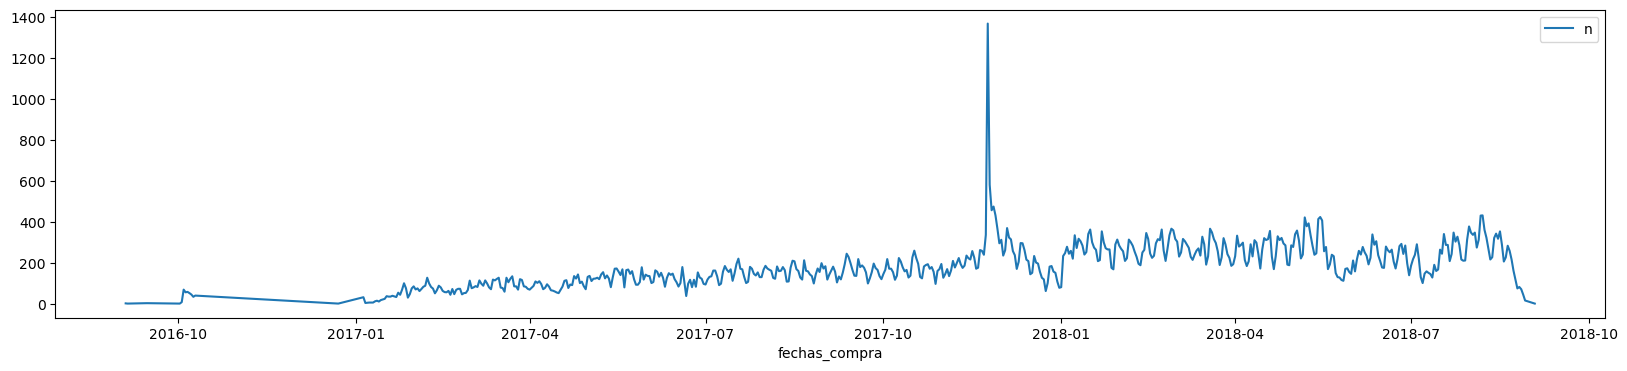

In [406]:
serie_compras.plot(x = "fechas_compra", y = "n", figsize = (20, 4))

Ahora vamos a analizar como se correlaciona la serie con sus rezagos:

In [408]:
serie_compras.head()

,fechas_compra,n
0,2016-09-04,2
1,2016-09-05,1
2,2016-09-15,3
3,2016-10-02,1
4,2016-10-03,8


In [409]:
# Rezago (lag) de 1
serie_compras["n"].shift(1)

0       NaN
1       2.0
2       1.0
3       3.0
4       1.0
       ... 
611    75.0
612    82.0
613    71.0
614    45.0
615    16.0
Name: n, Length: 616, dtype: float64

In [410]:
# Rezago (lag) de 2
serie_compras["n"].shift(2)

0        NaN
1        NaN
2        2.0
3        1.0
4        3.0
       ...  
611    117.0
612     75.0
613     82.0
614     71.0
615     45.0
Name: n, Length: 616, dtype: float64

In [411]:
# Hacia adelante (lead) de 1
serie_compras["n"].shift(-1)

0       1.0
1       3.0
2       1.0
3       8.0
4      69.0
       ... 
611    71.0
612    45.0
613    16.0
614     1.0
615     NaN
Name: n, Length: 616, dtype: float64

In [412]:
# Hacia adelante (lead) de 2
serie_compras["n"].shift(-2)

0       3.0
1       1.0
2       8.0
3      69.0
4      56.0
       ... 
611    45.0
612    16.0
613     1.0
614     NaN
615     NaN
Name: n, Length: 616, dtype: float64

Vamos a utilizar la función `np.corrcoef()` para calcular la correlación entre la serie y sus rezagos:

$$\rho_{X,Y} = \frac{\sigma_{XY}}{\sigma_X \sigma_Y} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2}\sqrt{\sum (y_i - \bar{y})^2}}.$$

In [422]:
# Correlación del numero de ventas diarias con su serie rezagada 1, 2, ... 30, días 
correlaciones = []
for i in range(1,31):   
    # Ojo. Cuando creamos los rezagos, tenemos NAs (no sabemos que hay antes de la primera observación)
    # Luego, es necesario no tener en cuenta los períodos faltantes en el cálculo de la correlación 
    X = serie_compras["n"][i:]
    Y = serie_compras["n"].shift(i)[i:]
    corr = np.corrcoef(X, Y)
    corr = corr[1,0]
    correlaciones.append(corr) 

Note que en la medida que aumenta el rezago, se disminuye la correlación, sin embargo, hay un patrón en el que rezagos múltiplos de 7 tienen una correlación superior a la esperada. Esto señala que nuestra serie tiene un efecto semanal, las ventas se pueden explicar en gran medida por el día de la semana.

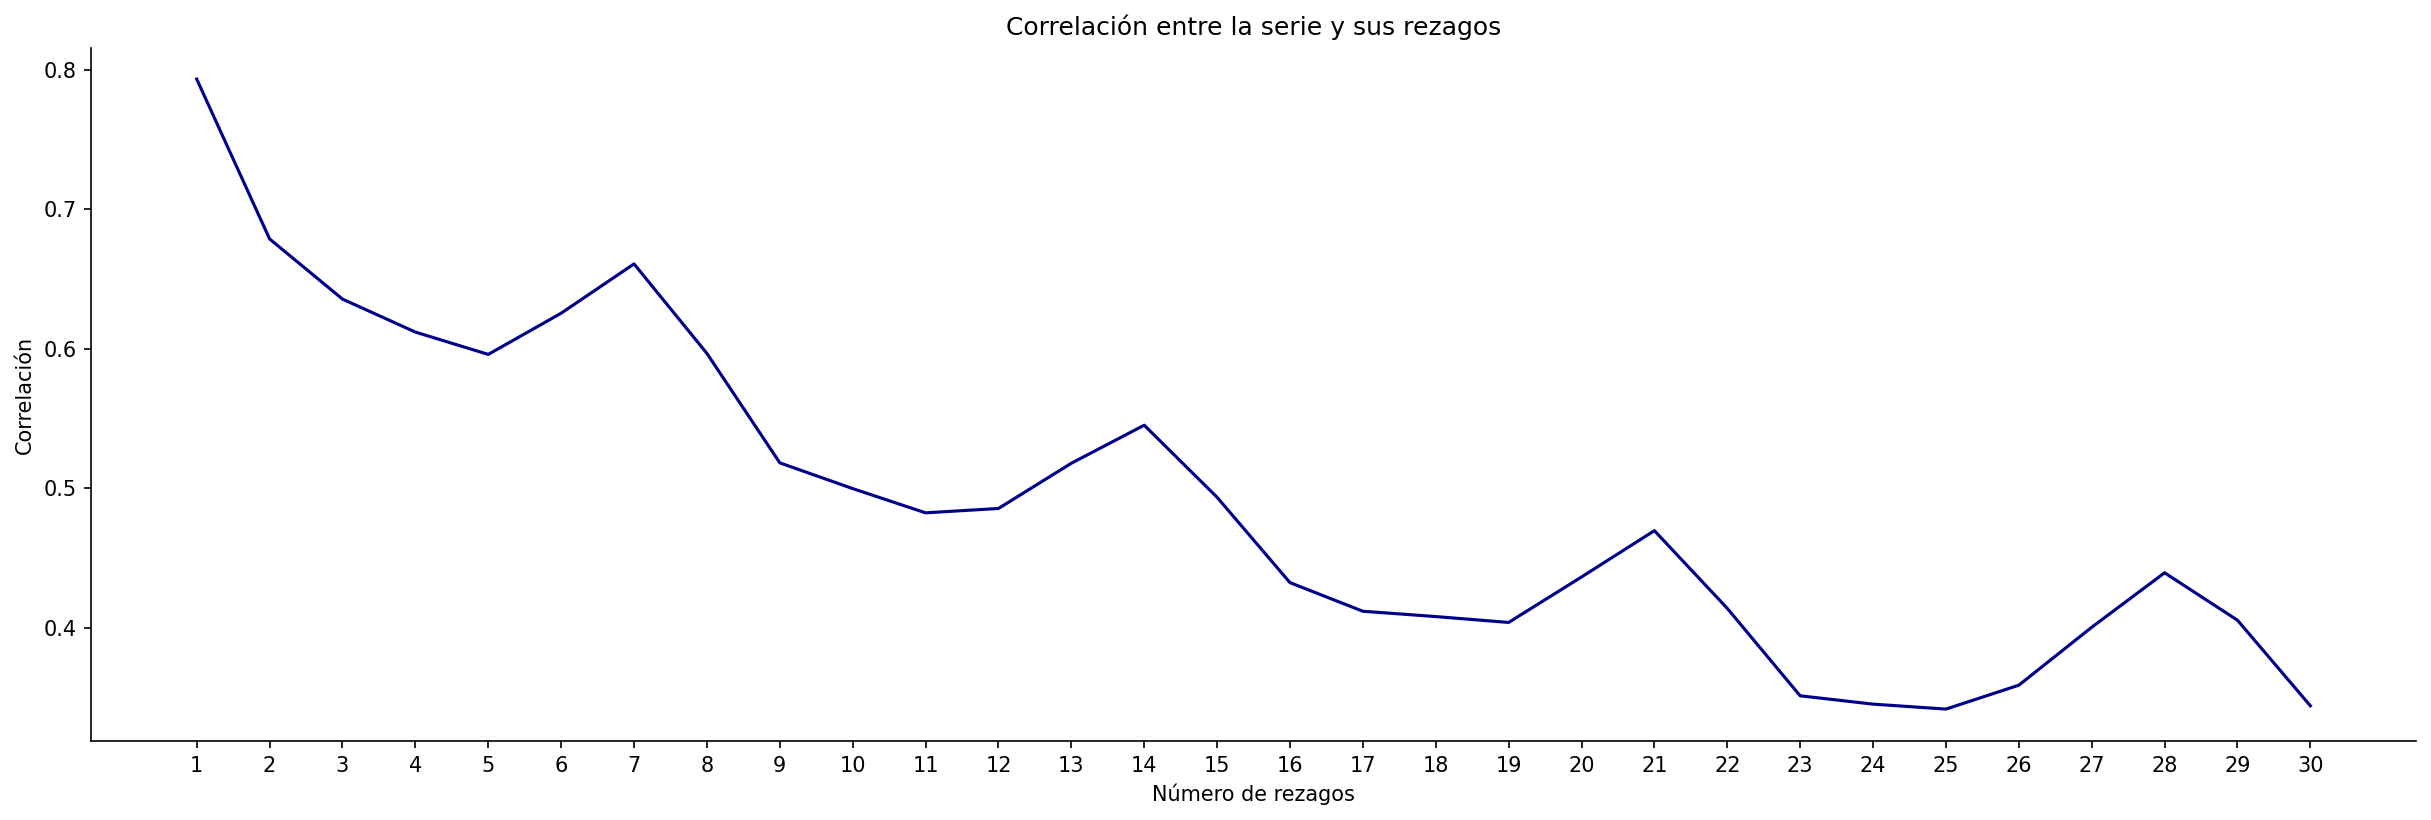

In [432]:
fig, ax = plt.subplots(figsize = (20,6), dpi = 150)
sns.despine()
plt.plot(range(1,31), correlaciones, color = "darkblue")
plt.xticks(range(1,31),range(1,31));
plt.title("Correlación entre la serie y sus rezagos");
plt.xlabel("Número de rezagos");
plt.ylabel("Correlación");

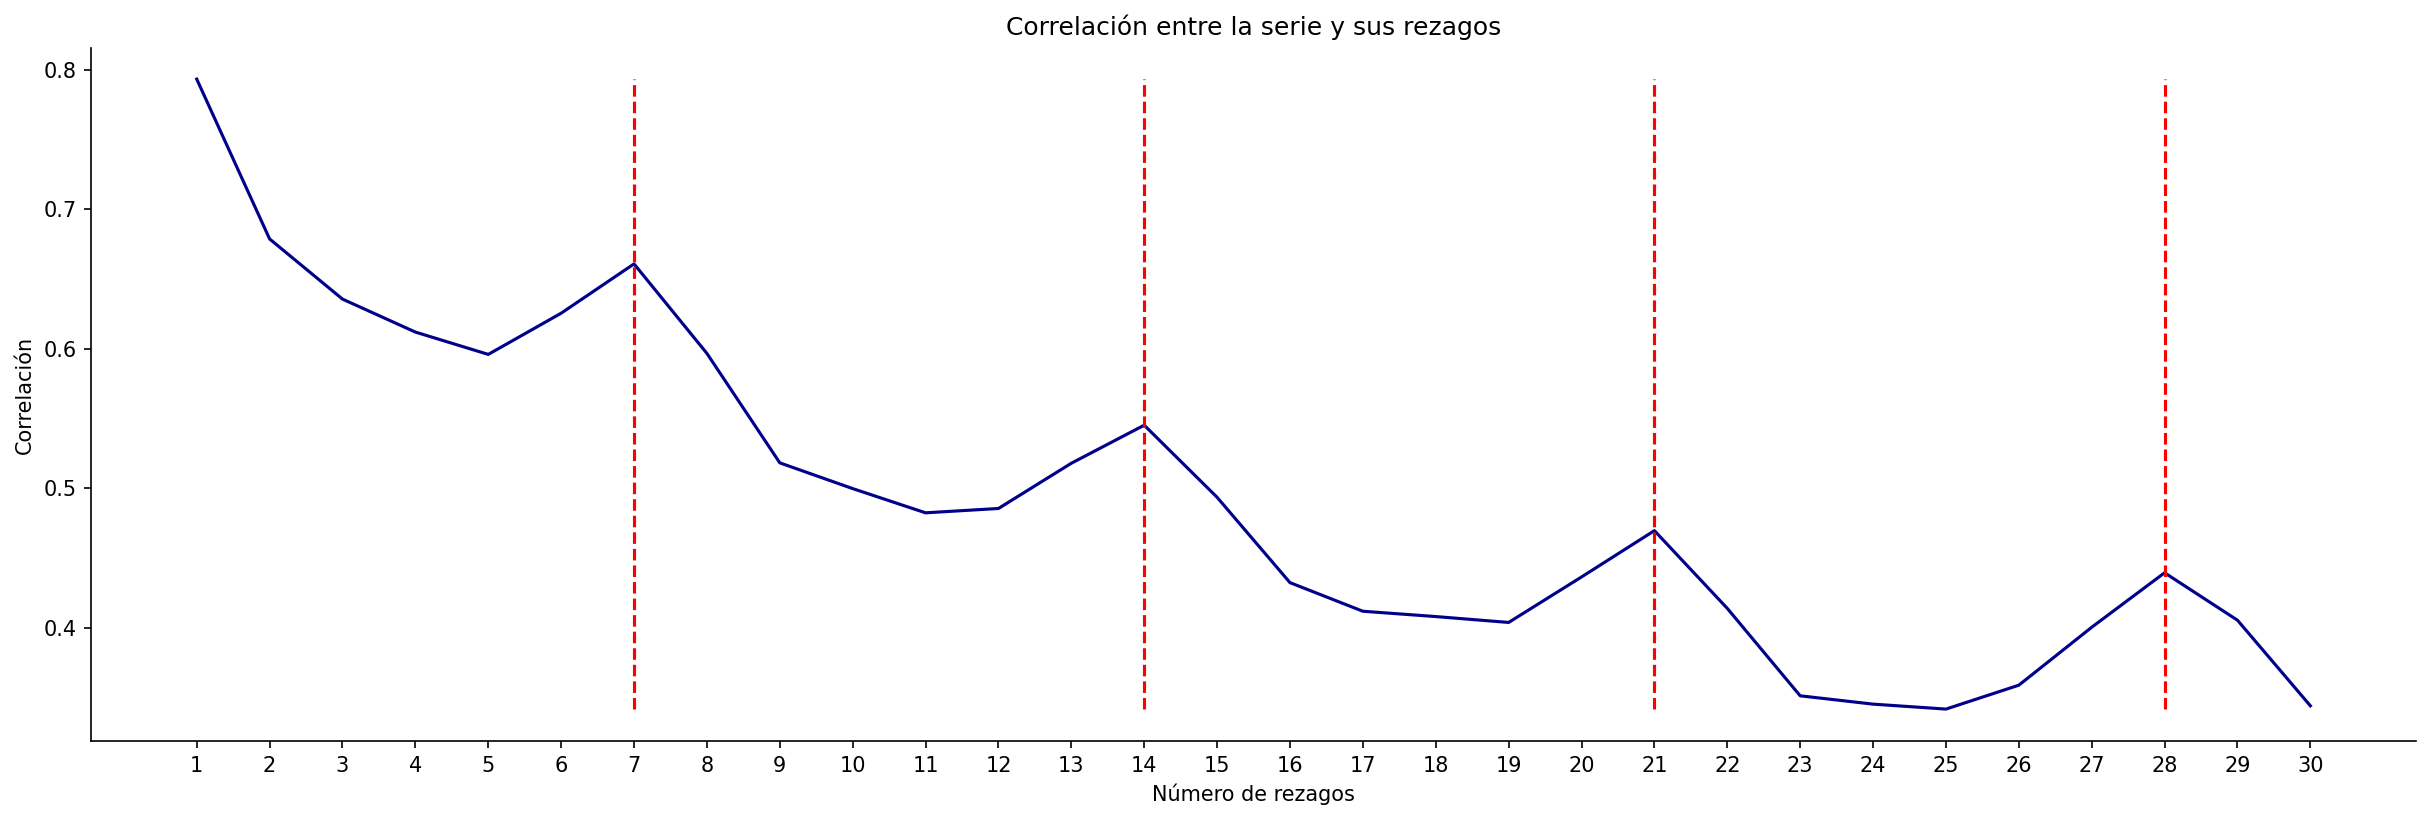

In [437]:
fig, ax = plt.subplots(figsize = (20,6), dpi = 150)
sns.despine()
plt.plot(range(1,31), correlaciones, color = "darkblue")
plt.xticks(range(1,31),range(1,31));
plt.title("Correlación entre la serie y sus rezagos");
plt.xlabel("Número de rezagos");
plt.ylabel("Correlación");
# Pintamos lineas verticales en rojo desde 7 hasta 31 dando saltos de 7 unidades.
plt.vlines(range(7, 31, 7), min(correlaciones), max(correlaciones), colors = 'red', linestyles = "dashed");

Vamos a construir la serie rezagada 7 días para analizar su comportamiento

In [447]:
# Rezagamos la serie 7 días (una semana)
serie_compras["n_l7"] = serie_compras["n"].shift(7)

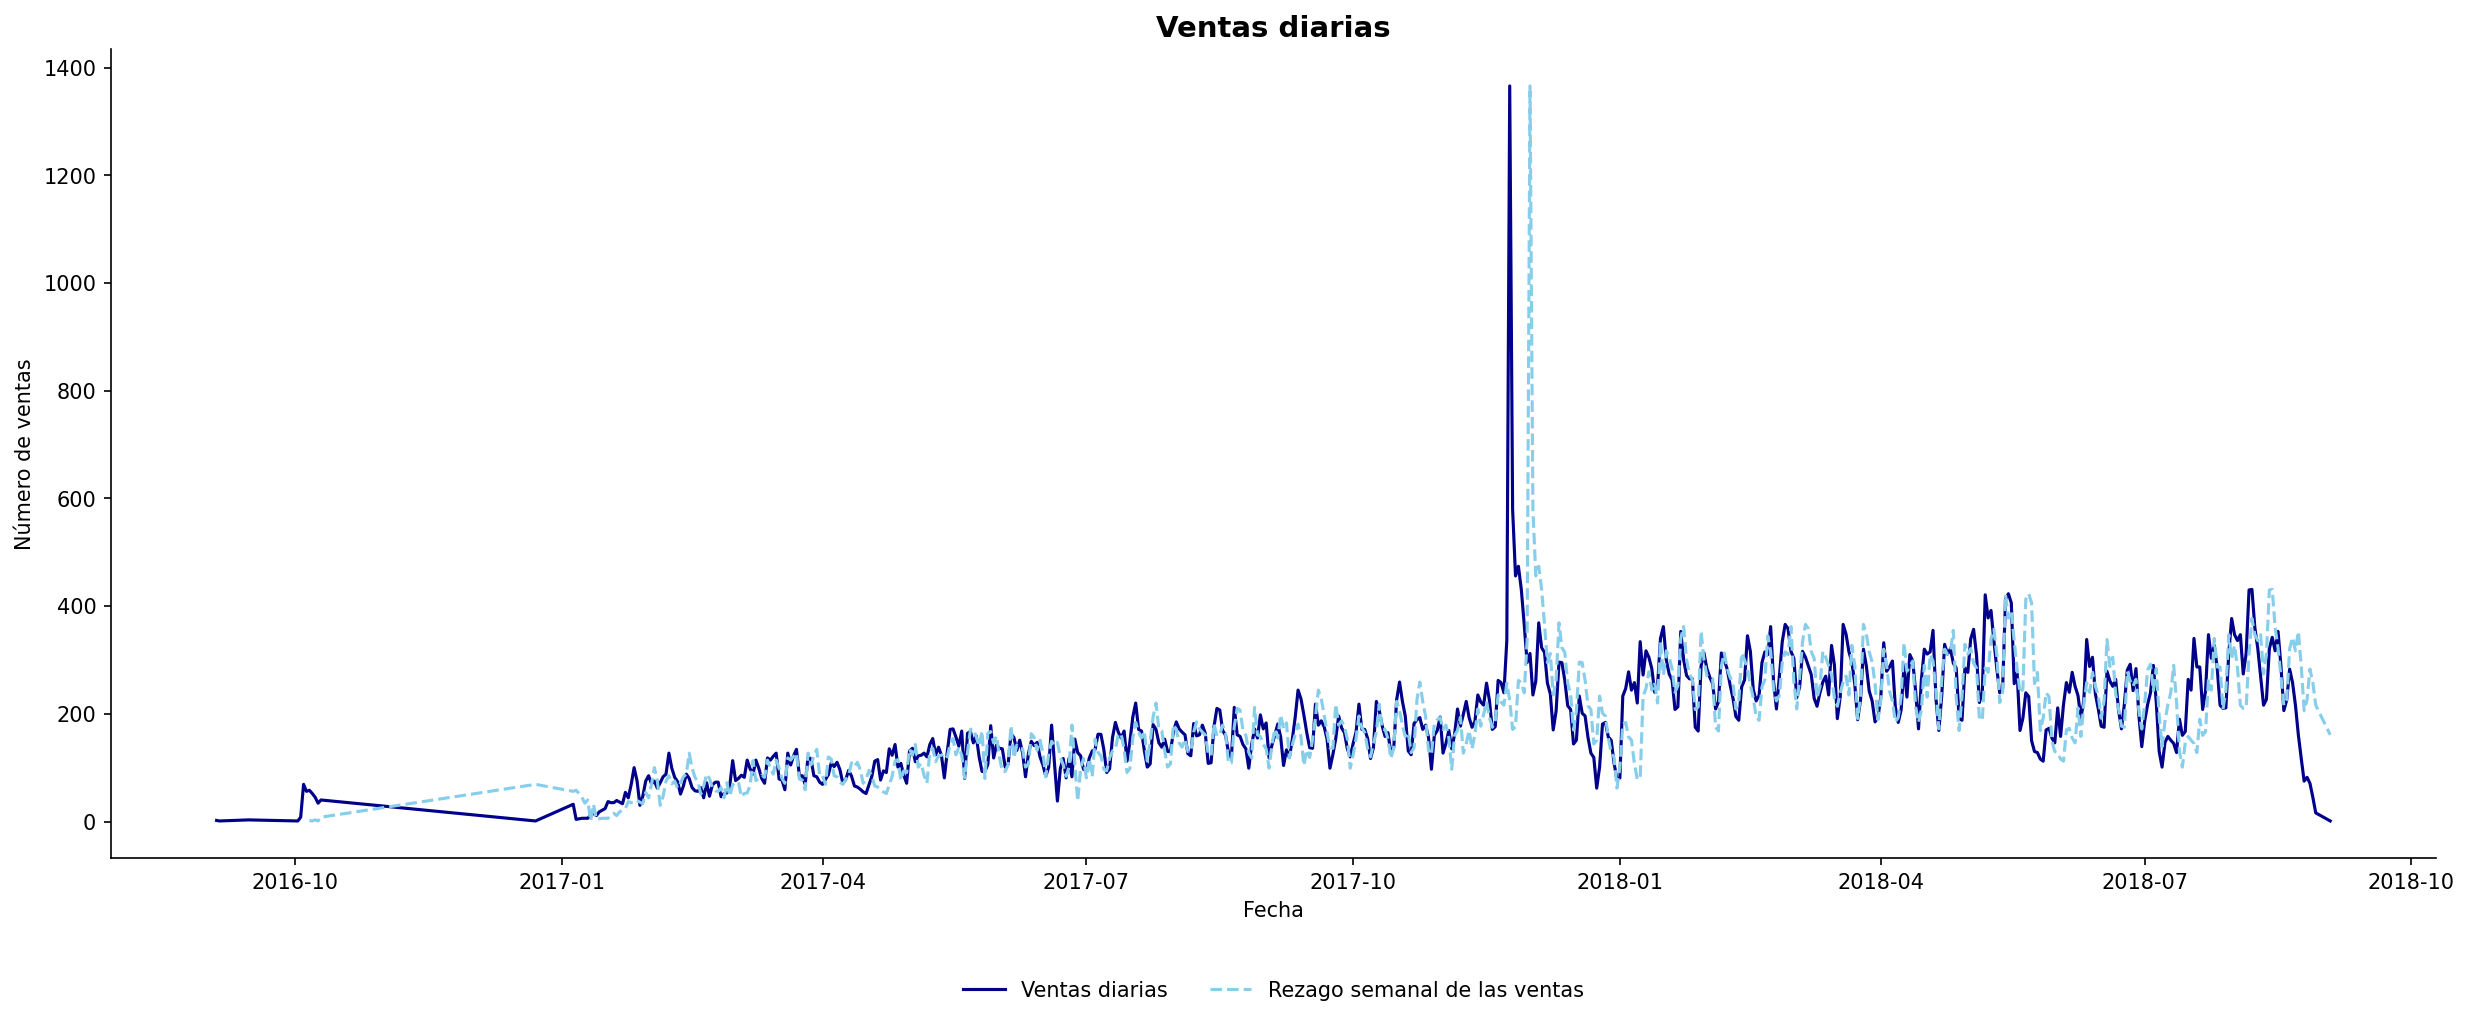

In [469]:
fig, ax = plt.subplots(figsize = (20, 7), dpi = 150)
sns.despine()
plt.plot(serie_compras["fechas_compra"], serie_compras["n"], color = "darkblue")
plt.plot(serie_compras["fechas_compra"], serie_compras["n_l7"], color = "skyblue", linestyle = "dashed")
plt.legend(['Ventas diarias', 'Rezago semanal de las ventas'], loc = "lower center", 
           bbox_to_anchor = (0.5, -0.2), ncol = 2, frameon = False);
plt.xlabel("Fecha");
plt.ylabel("Número de ventas");
plt.title("Ventas diarias", fontsize = 14, fontweight = "bold");

In [474]:
# Cojamos solo los últimos 3 meses
fecha_maxima = serie_compras["fechas_compra"].max()
fecha_maxima

datetime.date(2018, 9, 3)

In [485]:
from dateutil.relativedelta import *
punto_corte = fecha_maxima - relativedelta(months = 3)
punto_corte

datetime.date(2018, 6, 3)

In [489]:
ultimos_meses = serie_compras.loc[serie_compras["fechas_compra"] >= punto_corte,]
ultimos_meses.head()

,fechas_compra,n,n_l7
527,2018-06-03,217,112.0
528,2018-06-04,258,170.0
529,2018-06-05,240,173.0
530,2018-06-06,277,155.0
531,2018-06-07,251,146.0


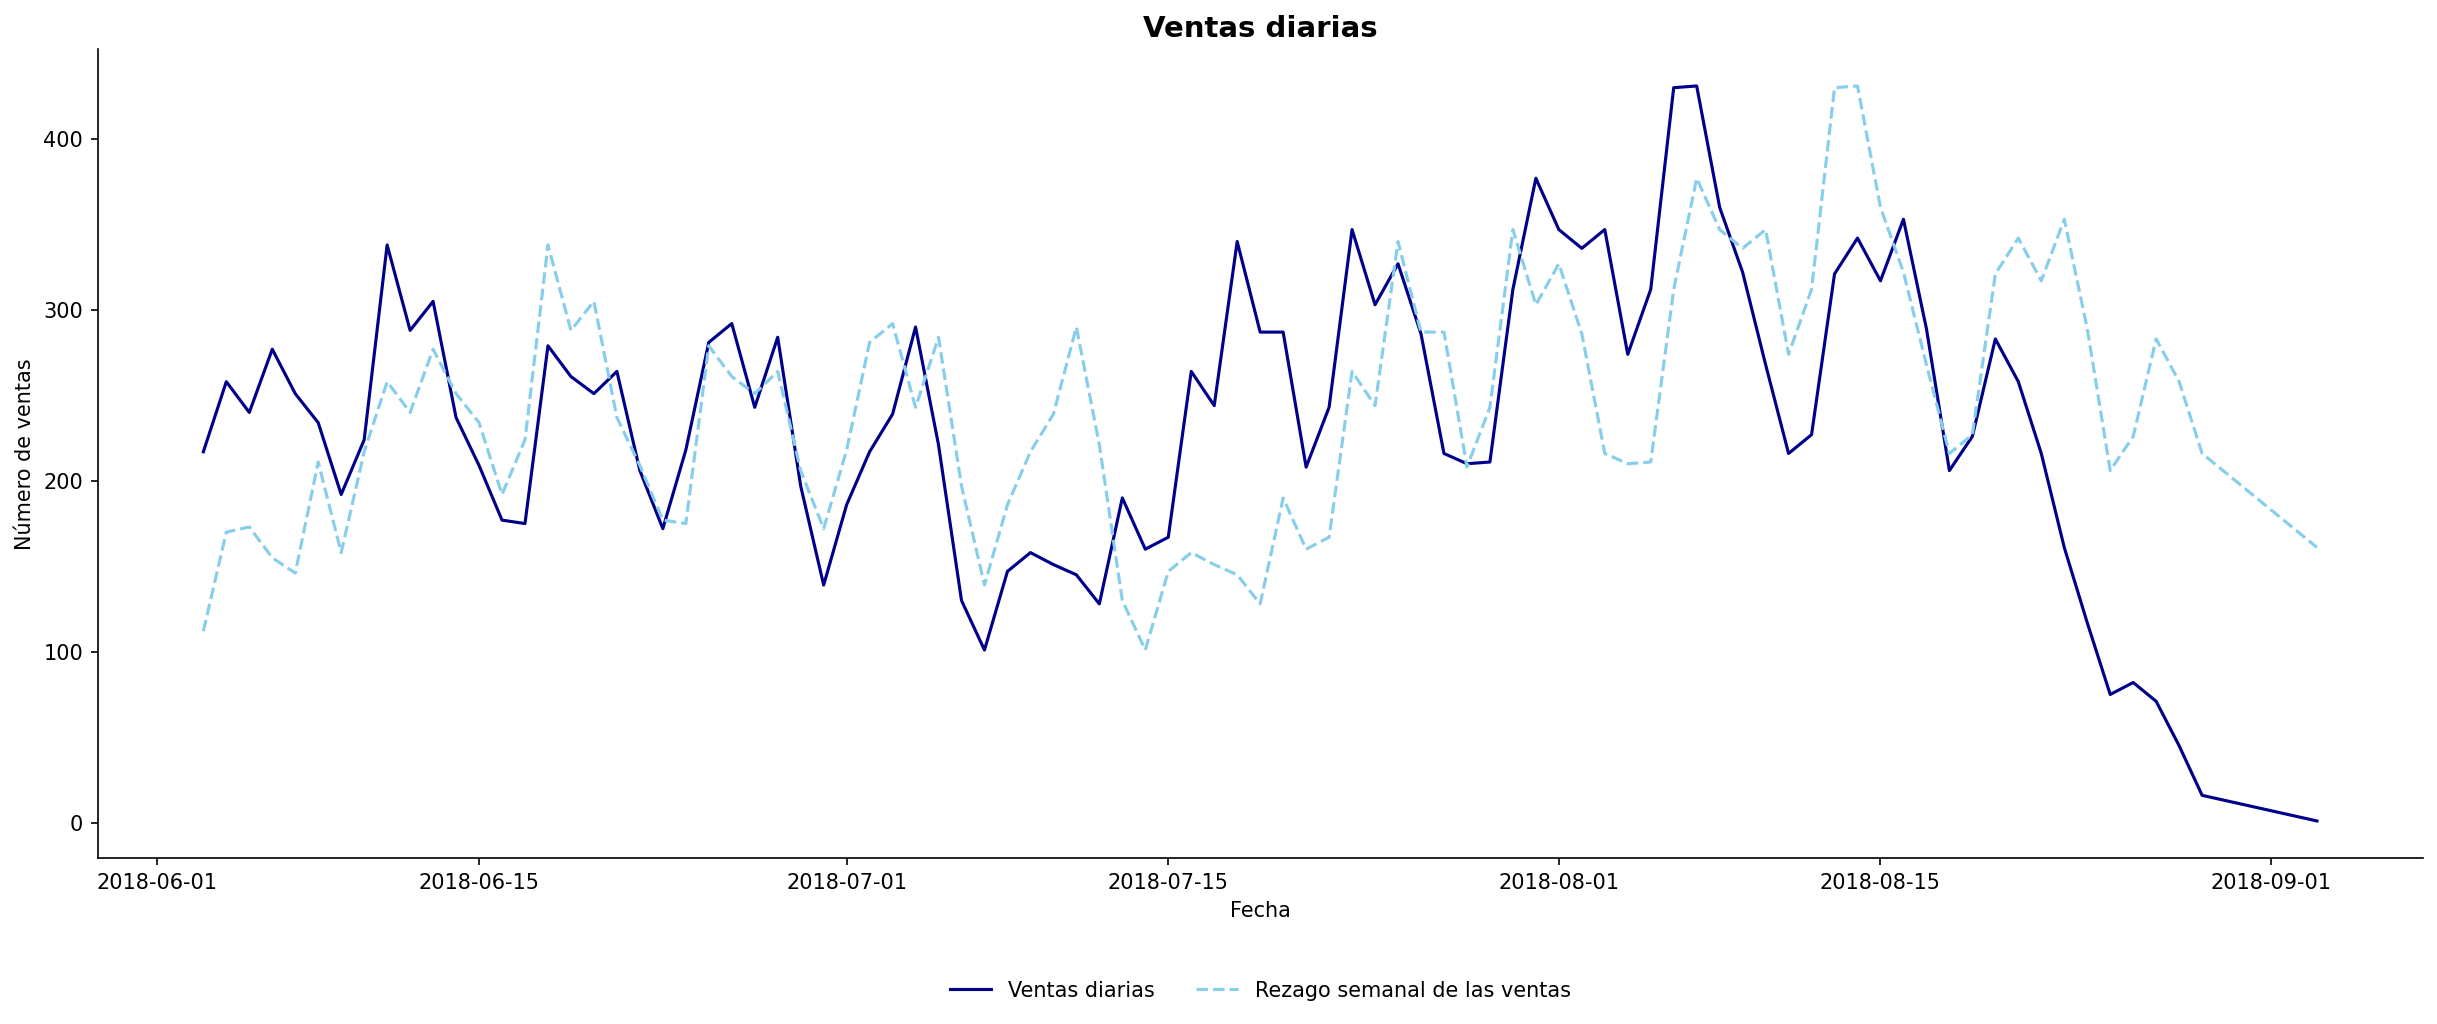

In [490]:
fig, ax = plt.subplots(figsize = (20, 7), dpi = 150)
sns.despine()
plt.plot(ultimos_meses["fechas_compra"], ultimos_meses["n"], color = "darkblue")
plt.plot(ultimos_meses["fechas_compra"], ultimos_meses["n_l7"], color = "skyblue", linestyle = "dashed")
plt.legend(['Ventas diarias', 'Rezago semanal de las ventas'], loc = "lower center", 
           bbox_to_anchor = (0.5, -0.2), ncol = 2, frameon = False);
plt.xlabel("Fecha");
plt.ylabel("Número de ventas");
plt.title("Ventas diarias", fontsize = 14, fontweight = "bold");

Calculemos la diferencia entre el valor real y el rezago

In [494]:
serie_compras["diferencia"] = serie_compras["n"] - serie_compras["n_l7"]

Otra forma de hacerlo

In [496]:
serie_compras["diferencia2"] = serie_compras["n"].diff(7)

In [499]:
serie_compras.tail()

,fechas_compra,n,n_l7,diferencia,diferencia2
611,2018-08-26,82,226.0,-144.0,-144.0
612,2018-08-27,71,283.0,-212.0,-212.0
613,2018-08-28,45,258.0,-213.0,-213.0
614,2018-08-29,16,216.0,-200.0,-200.0
615,2018-09-03,1,161.0,-160.0,-160.0


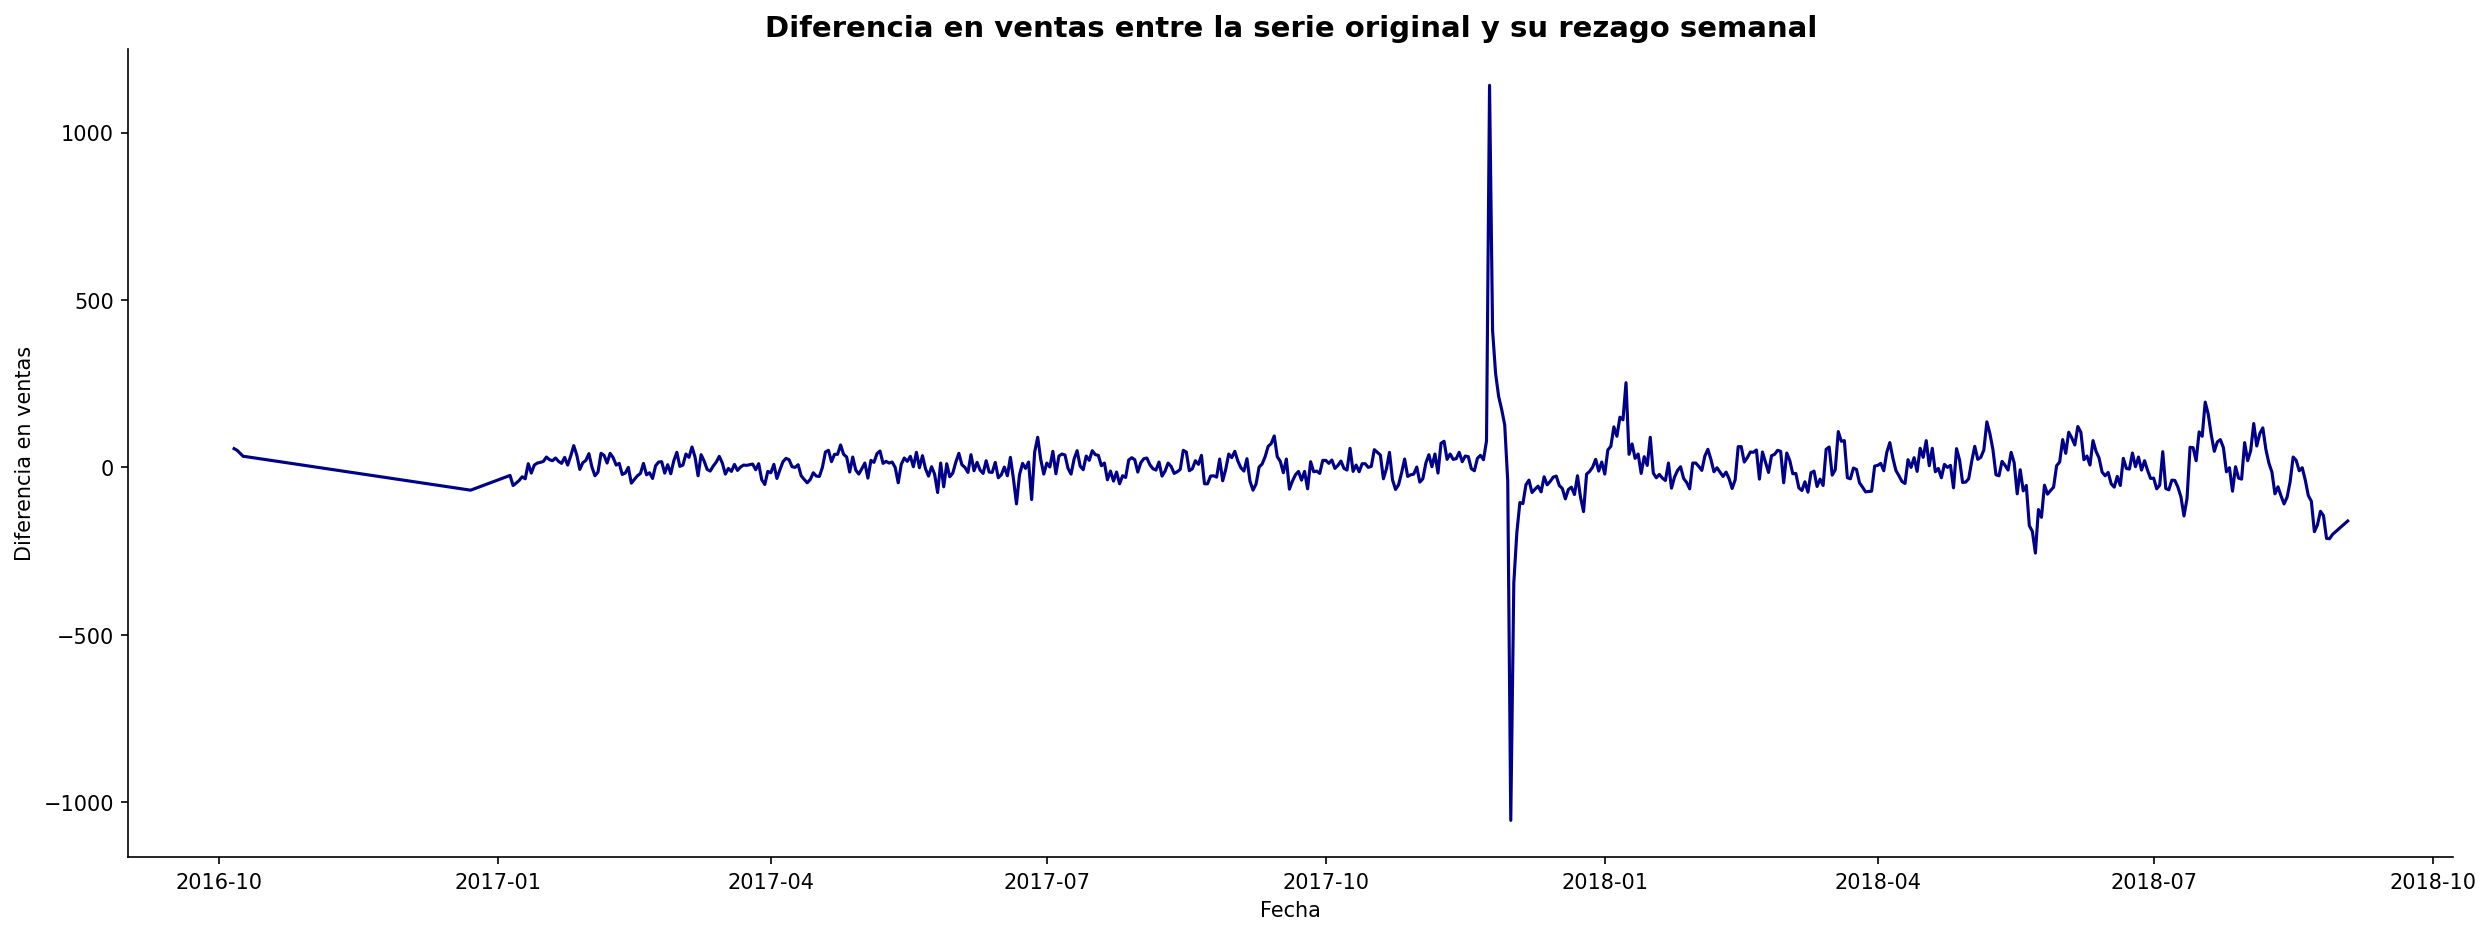

In [501]:
fig, ax = plt.subplots(figsize = (20, 7), dpi = 150)
sns.despine()
plt.plot(serie_compras["fechas_compra"], serie_compras["diferencia"], color = "darkblue")
plt.xlabel("Fecha");
plt.ylabel("Diferencia en ventas");
plt.title("Diferencia en ventas entre la serie original y su rezago semanal", fontsize = 14, fontweight = "bold");

In [502]:
ultimos_meses = serie_compras.loc[serie_compras["fechas_compra"] >= punto_corte,]

Si nos deshacemos del período atípico en general está entre 200 y -200.

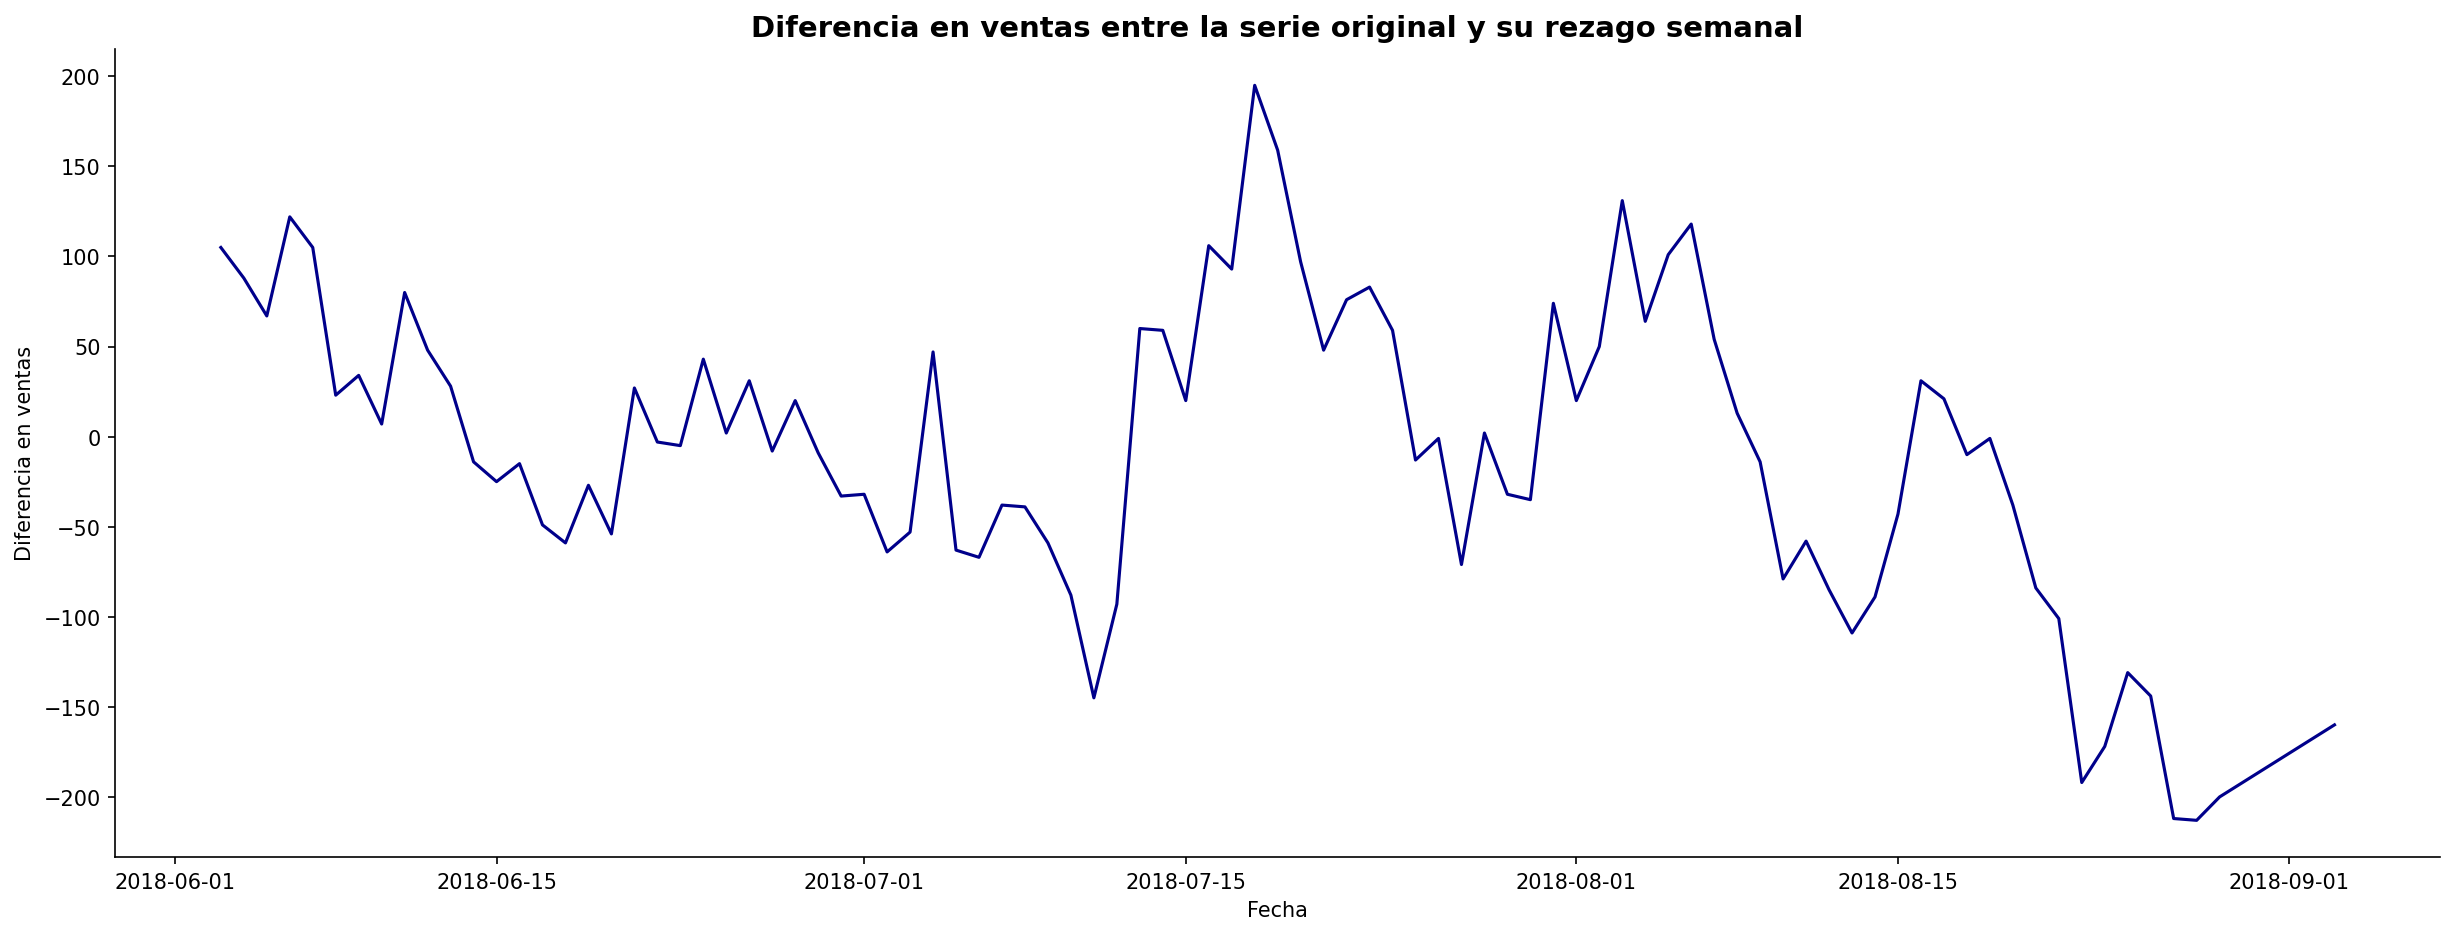

In [503]:
fig, ax = plt.subplots(figsize = (20, 7), dpi = 150)
sns.despine()
plt.plot(ultimos_meses["fechas_compra"], ultimos_meses["diferencia"], color = "darkblue")
plt.xlabel("Fecha");
plt.ylabel("Diferencia en ventas");
plt.title("Diferencia en ventas entre la serie original y su rezago semanal", fontsize = 14, fontweight = "bold");

In [505]:
ultimos_meses["diferencia"].describe()

count     89.000000
mean      -8.067416
std       84.934306
min     -213.000000
25%      -59.000000
50%       -5.000000
75%       50.000000
max      195.000000
Name: diferencia, dtype: float64

In [504]:
serie_compras["n"].describe()

count     616.000000
mean      182.873377
std       105.888023
min         1.000000
25%       112.000000
50%       169.000000
75%       245.250000
max      1366.000000
Name: n, dtype: float64

9. Convierta la variable de monto de pago a categórica y grafique el número de transacciones en cada categoría creada.

In [506]:
pagos['payment_value'].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [507]:
# pd.cut() nos permite pasar una variable continua a categórica 
pagos['categoria_pago'] = pd.cut(pagos['payment_value'],                           
                                 # Pasamos los limites de los intervalos en los que se divide la variable. 
                                 # También se puede decir el número de grupos en los que se desea dividir: bins = 5.               
                                 bins = [0, 50, 100, 200, 1000, pagos['payment_value'].max()],    
                                 # Los nombres de las categorías creadas. Por ejemplo, la categoría bajo corresponde a 0 < pagos <= 50
                                 labels = ['Bajo', 'Medio-Bajo', 'Medio', 'Medio-Alto', 'Alto'])  

In [508]:
pagos['categoria_pago']

0         Medio-Bajo
1               Bajo
2         Medio-Bajo
3              Medio
4              Medio
             ...    
103881    Medio-Alto
103882    Medio-Bajo
103883          Bajo
103884    Medio-Alto
103885         Medio
Name: categoria_pago, Length: 103886, dtype: category
Categories (5, object): ['Bajo' < 'Medio-Bajo' < 'Medio' < 'Medio-Alto' < 'Alto']

Text(0, 0.5, 'Cantidad')

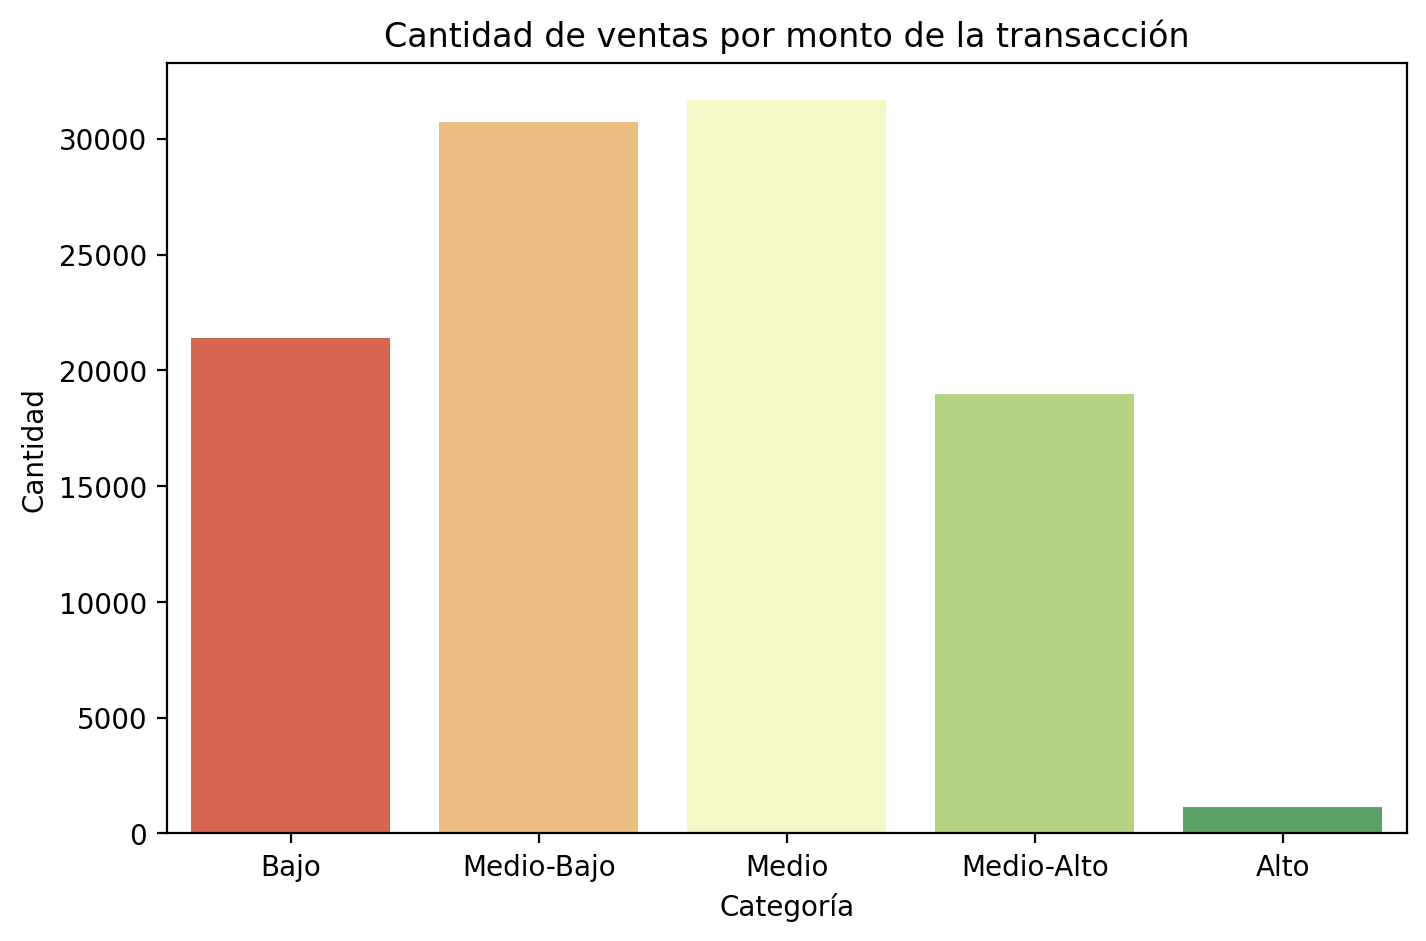

In [523]:
# Gráfico con seaborn que cuenta cuantas veces aparece cada categoría.
fig, ax = plt.subplots(figsize = (8, 5), dpi = 200)
sns.countplot(data = pagos, x = 'categoria_pago', palette = "RdYlGn", ax = ax) 
plt.title("Cantidad de ventas por monto de la transacción")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")

### Regresión Lineal
La regresión lineal es una técnica estadística utilizada para analizar la relación entre una variable una variable dependiente ($Y$) y un conjunto de variables explicativas ($X$). El objetivo de la regresión lineal es encontrar la mejor línea recta que pueda explicar la relación entre las variables y predecir el valor de $Y$ para cualquier valor dado de $X$.

La ecuación de la línea recta se representa como:

$$Y = \alpha + \beta X$$

Donde $\alpha$ es la intersección en $Y$, $\beta$ es la pendiente de la línea recta y $X$ es el valor de la variable independiente. La pendiente de la línea recta indica cuánto aumenta (o disminuye) Y por cada unidad de cambio en $X$.

La regresión lineal se utiliza comúnmente en la investigación y en los negocios para predecir el valor de una variable dependiente en función de una variable independiente. Por ejemplo, se puede utilizar la regresión lineal para predecir la cantidad de ventas que una empresa puede esperar para un determinado nivel de publicidad.

1. Construya el pseudo volumen

In [556]:
ventas3["pseudo_volumen"] = ventas3['product_length_cm'] * ventas3['product_height_cm'] * ventas3['product_width_cm']

2. Construya un gráfico de dispersión entre el pseudo volumen y el precio de flete

<AxesSubplot:xlabel='pseudo_volumen', ylabel='freight_value'>

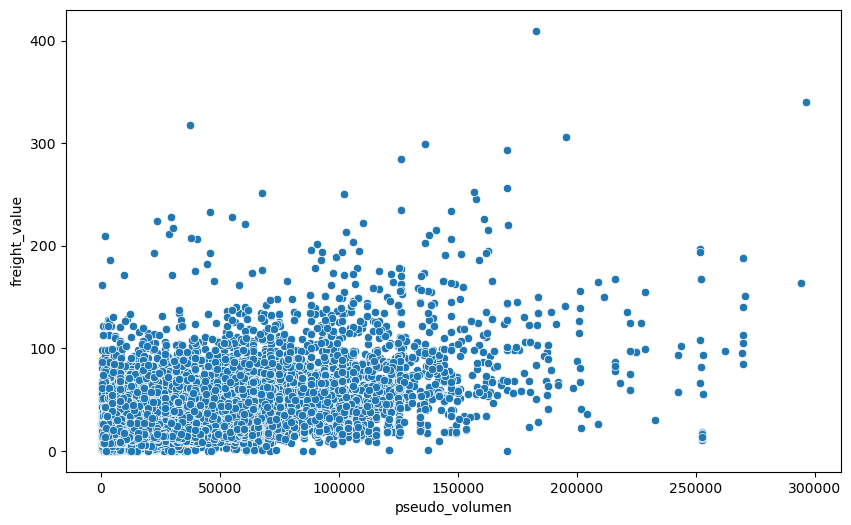

In [557]:
# Son demasiados puntos, no se puede observar con claridad.
fig, ax = plt.subplots(figsize = (10, 6))
sns.scatterplot(data = ventas3, x = "pseudo_volumen", y = "freight_value", ax = ax)

In [563]:
muestra = ventas3.sample(n = 1000, random_state = 666)

<AxesSubplot:xlabel='pseudo_volumen', ylabel='freight_value'>

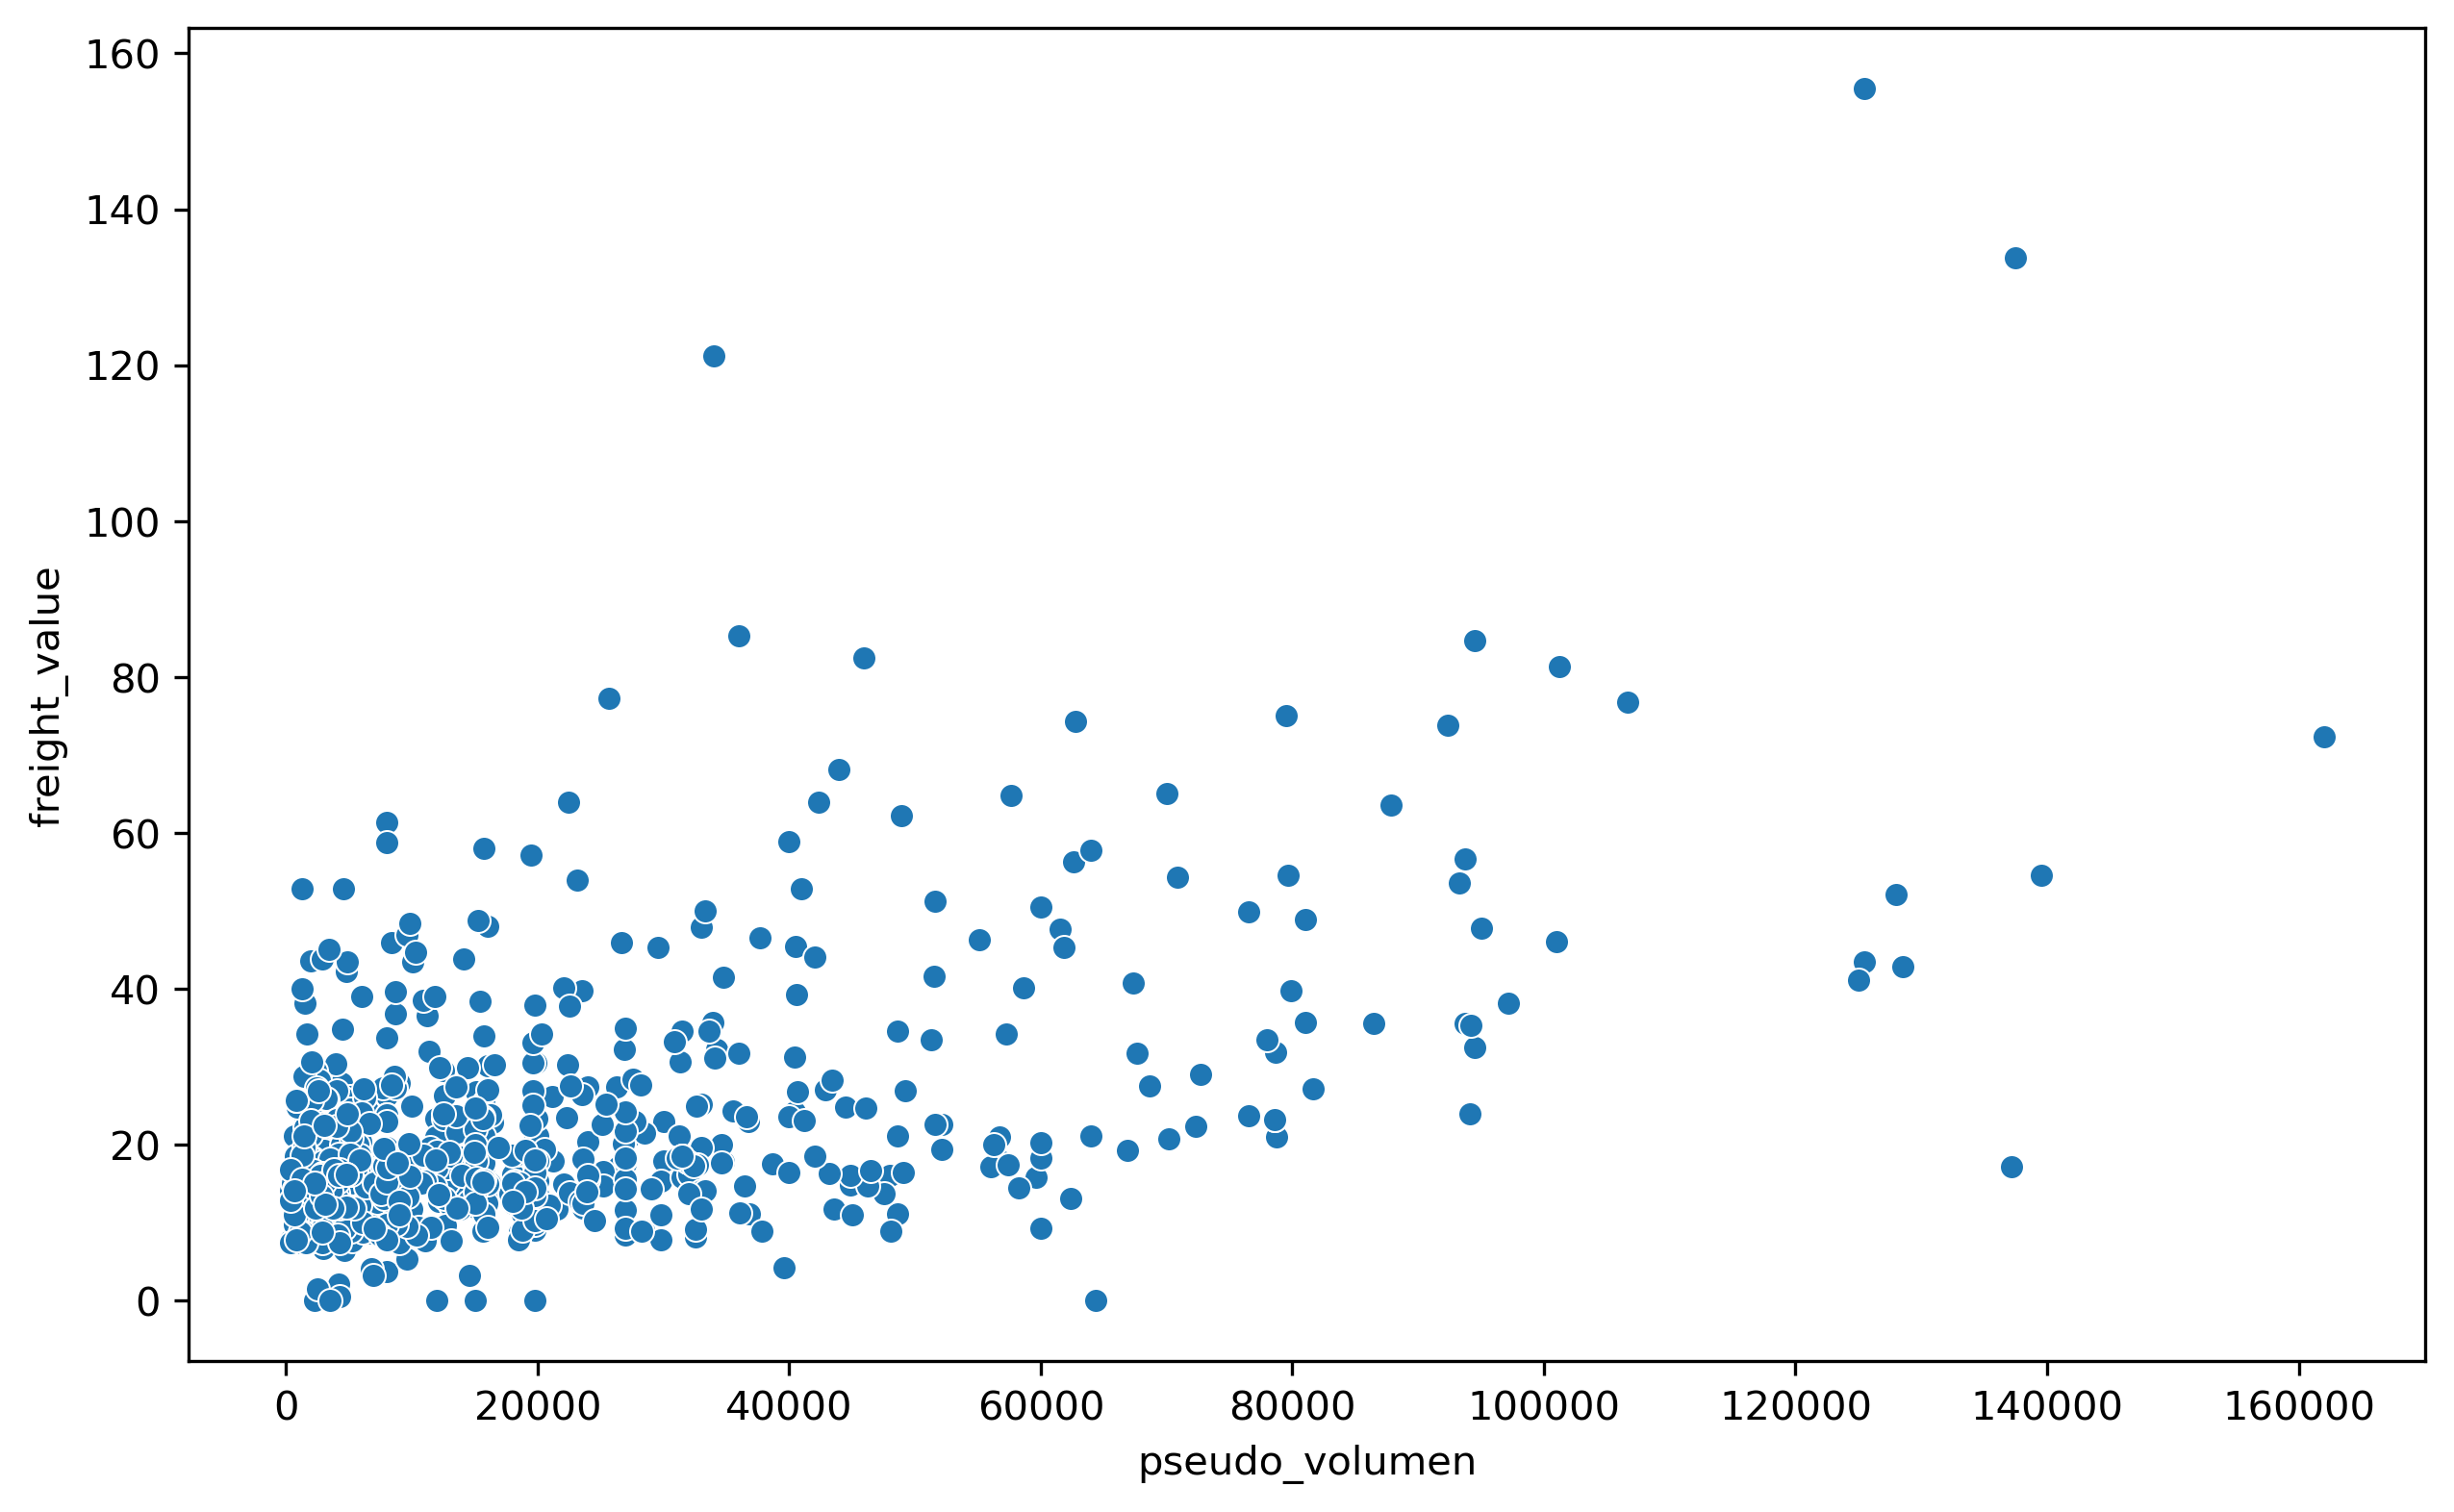

In [560]:
fig, ax = plt.subplots(figsize = (10, 6), dpi = 300)
sns.scatterplot(data = muestra, x = "pseudo_volumen", y = "freight_value", ax = ax)

Text(0, 0.5, 'Valor del flete')

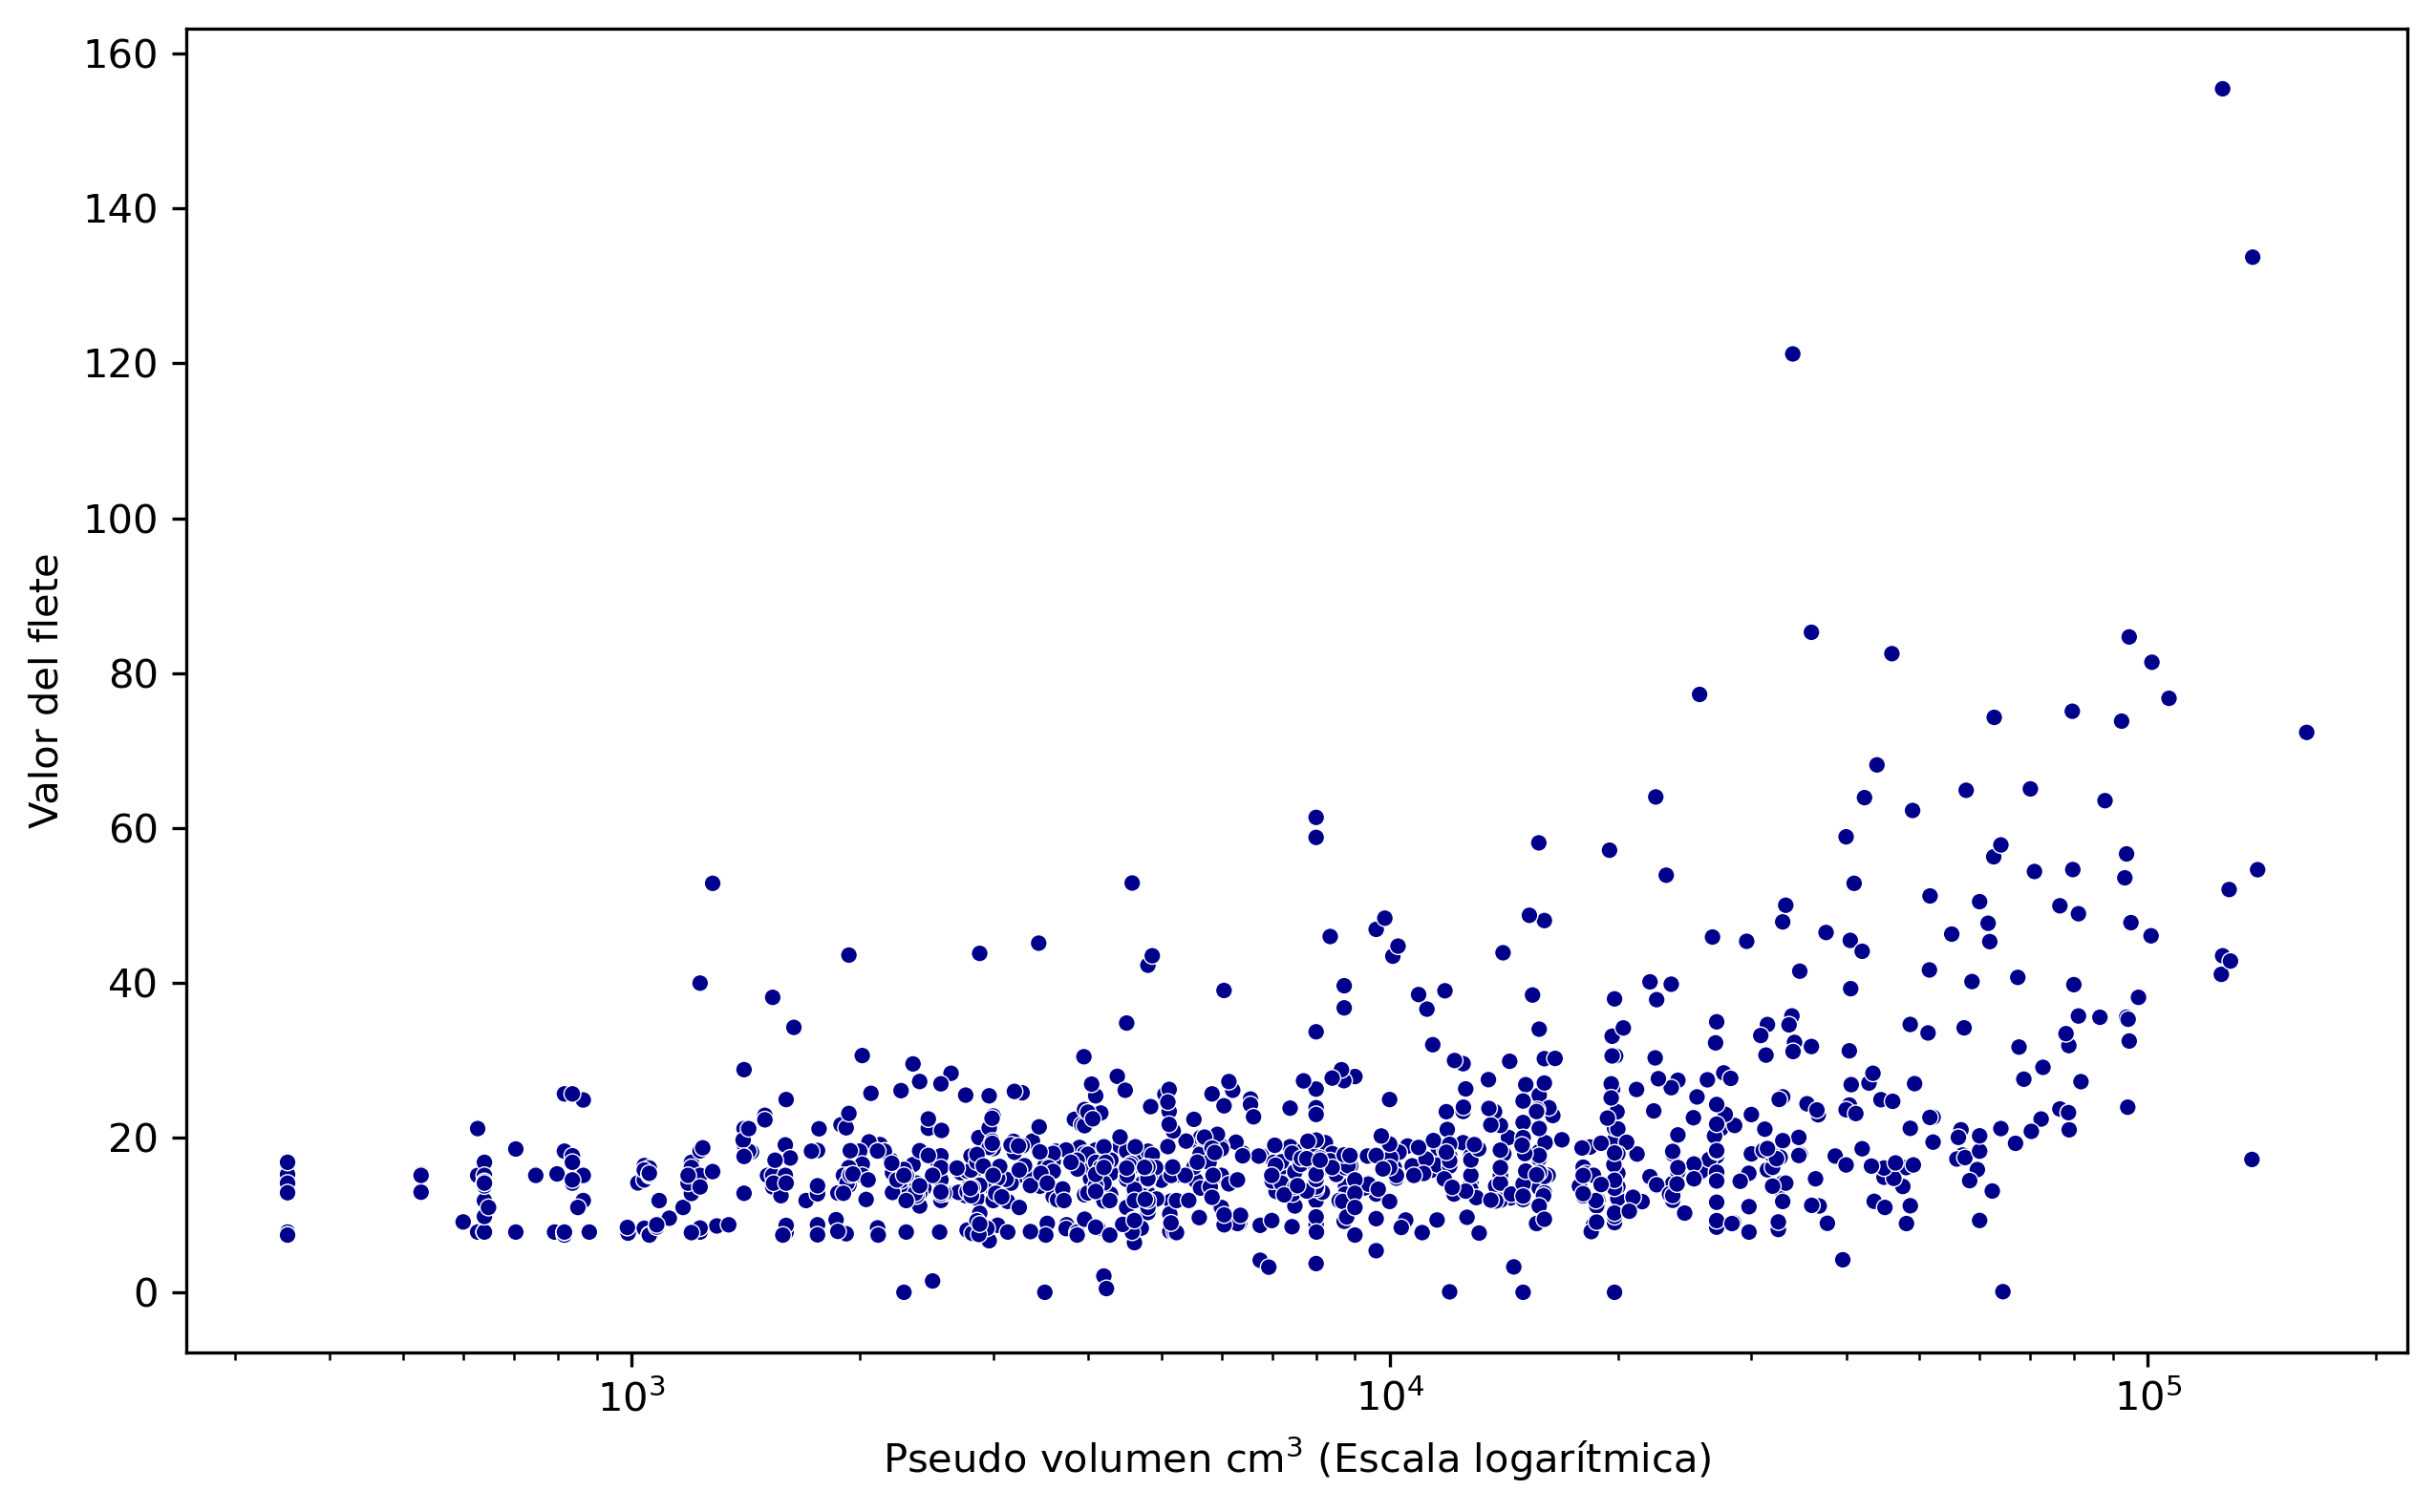

In [562]:
fig, ax = plt.subplots(figsize = (10, 6), dpi = 300)
sns.scatterplot(data = muestra, x = "pseudo_volumen", y = "freight_value", 
                color = "darkblue", size = 1, legend = False,
                ax = ax)
plt.xscale('log')
plt.xlabel("Pseudo volumen cm$^3$ (Escala logarítmica)")
plt.ylabel("Valor del flete")

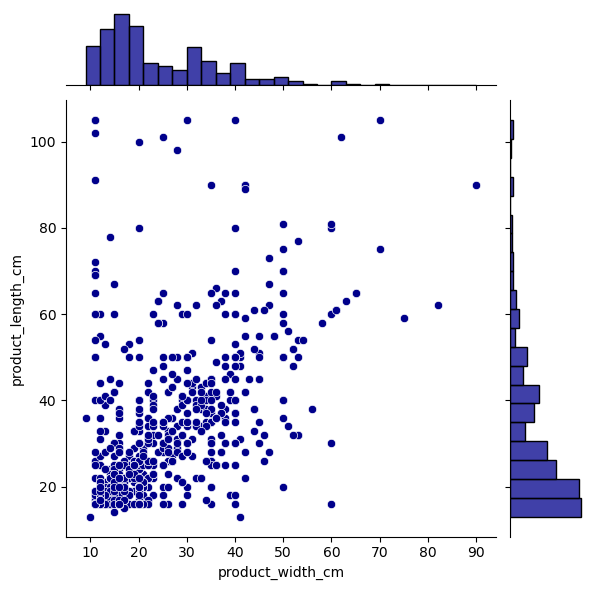

In [584]:
# Veamos la distribución conjunta entre ancho y largo
sns.jointplot(data = muestra, x = "product_width_cm", y = "product_length_cm", 
              color = "darkblue")

3. Construya la regresión entre el precio del flete y el pseudo volumen:
$$ precio\_flete_i = \alpha + \beta*pseudo\_volumen_i +\varepsilon_i $$

In [590]:
import statsmodels.api as sm

In [595]:
# Creamos X
X = muestra[['pseudo_volumen']]
# Añadimos una constante
X = sm.add_constant(X)

X.head()

,const,pseudo_volumen
38228,1.0,2800.0
82076,1.0,5600.0
100895,1.0,3380.0
48299,1.0,1500.0
56861,1.0,3536.0


In [596]:
# Creamos variable y
y = muestra[['freight_value']]
y.head()

,freight_value
38228,14.10
82076,19.35
100895,19.53
48299,22.86
56861,8.90


In [606]:
# Planteamos el modelo
modelo1 = sm.OLS(endog = y, exog = X)
modelo1

In [607]:
# Entrenamos
resultado1 = modelo1.fit()

In [608]:
resultado1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          freight_value   R-squared:                       0.317
Model:                            OLS   Adj. R-squared:                  0.316
Method:                 Least Squares   F-statistic:                     462.7
Date:                Thu, 06 Apr 2023   Prob (F-statistic):           1.24e-84
Time:                        11:54:21   Log-Likelihood:                -3850.9
No. Observations:                1000   AIC:                             7706.
Df Residuals:                     998   BIC:                             7716.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             14.2343      0.445     32.012      0.000      13.362      15.107
pseudo_volumen     0.0003   1.62e-05     21.511      0.000       0.000       0.000
==============================================================================
Omnibus:                      599.531   Durbin-Watson:                   1.980
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             9293.251
Skew:                           2.447   Prob(JB):                         0.00
Kurtosis:                      17.110   Cond. No.                     3.39e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.39e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [636]:
delta = 10000
valor = np.round(resultado1.params["pseudo_volumen"] * delta, 2)
print("Por cada {:,.0f} cm cubicos extras en el artículo comprado, el precio del flete aumenta en ${} reales".format(delta, valor))

Por cada 10,000 cm cubicos extras en el artículo comprado, el precio del flete aumenta en $3.48 reales


In [612]:
# Construyamos el ajuste dentro de muestra
y_hat = resultado1.predict()

Text(0, 0.5, 'Valor del flete')

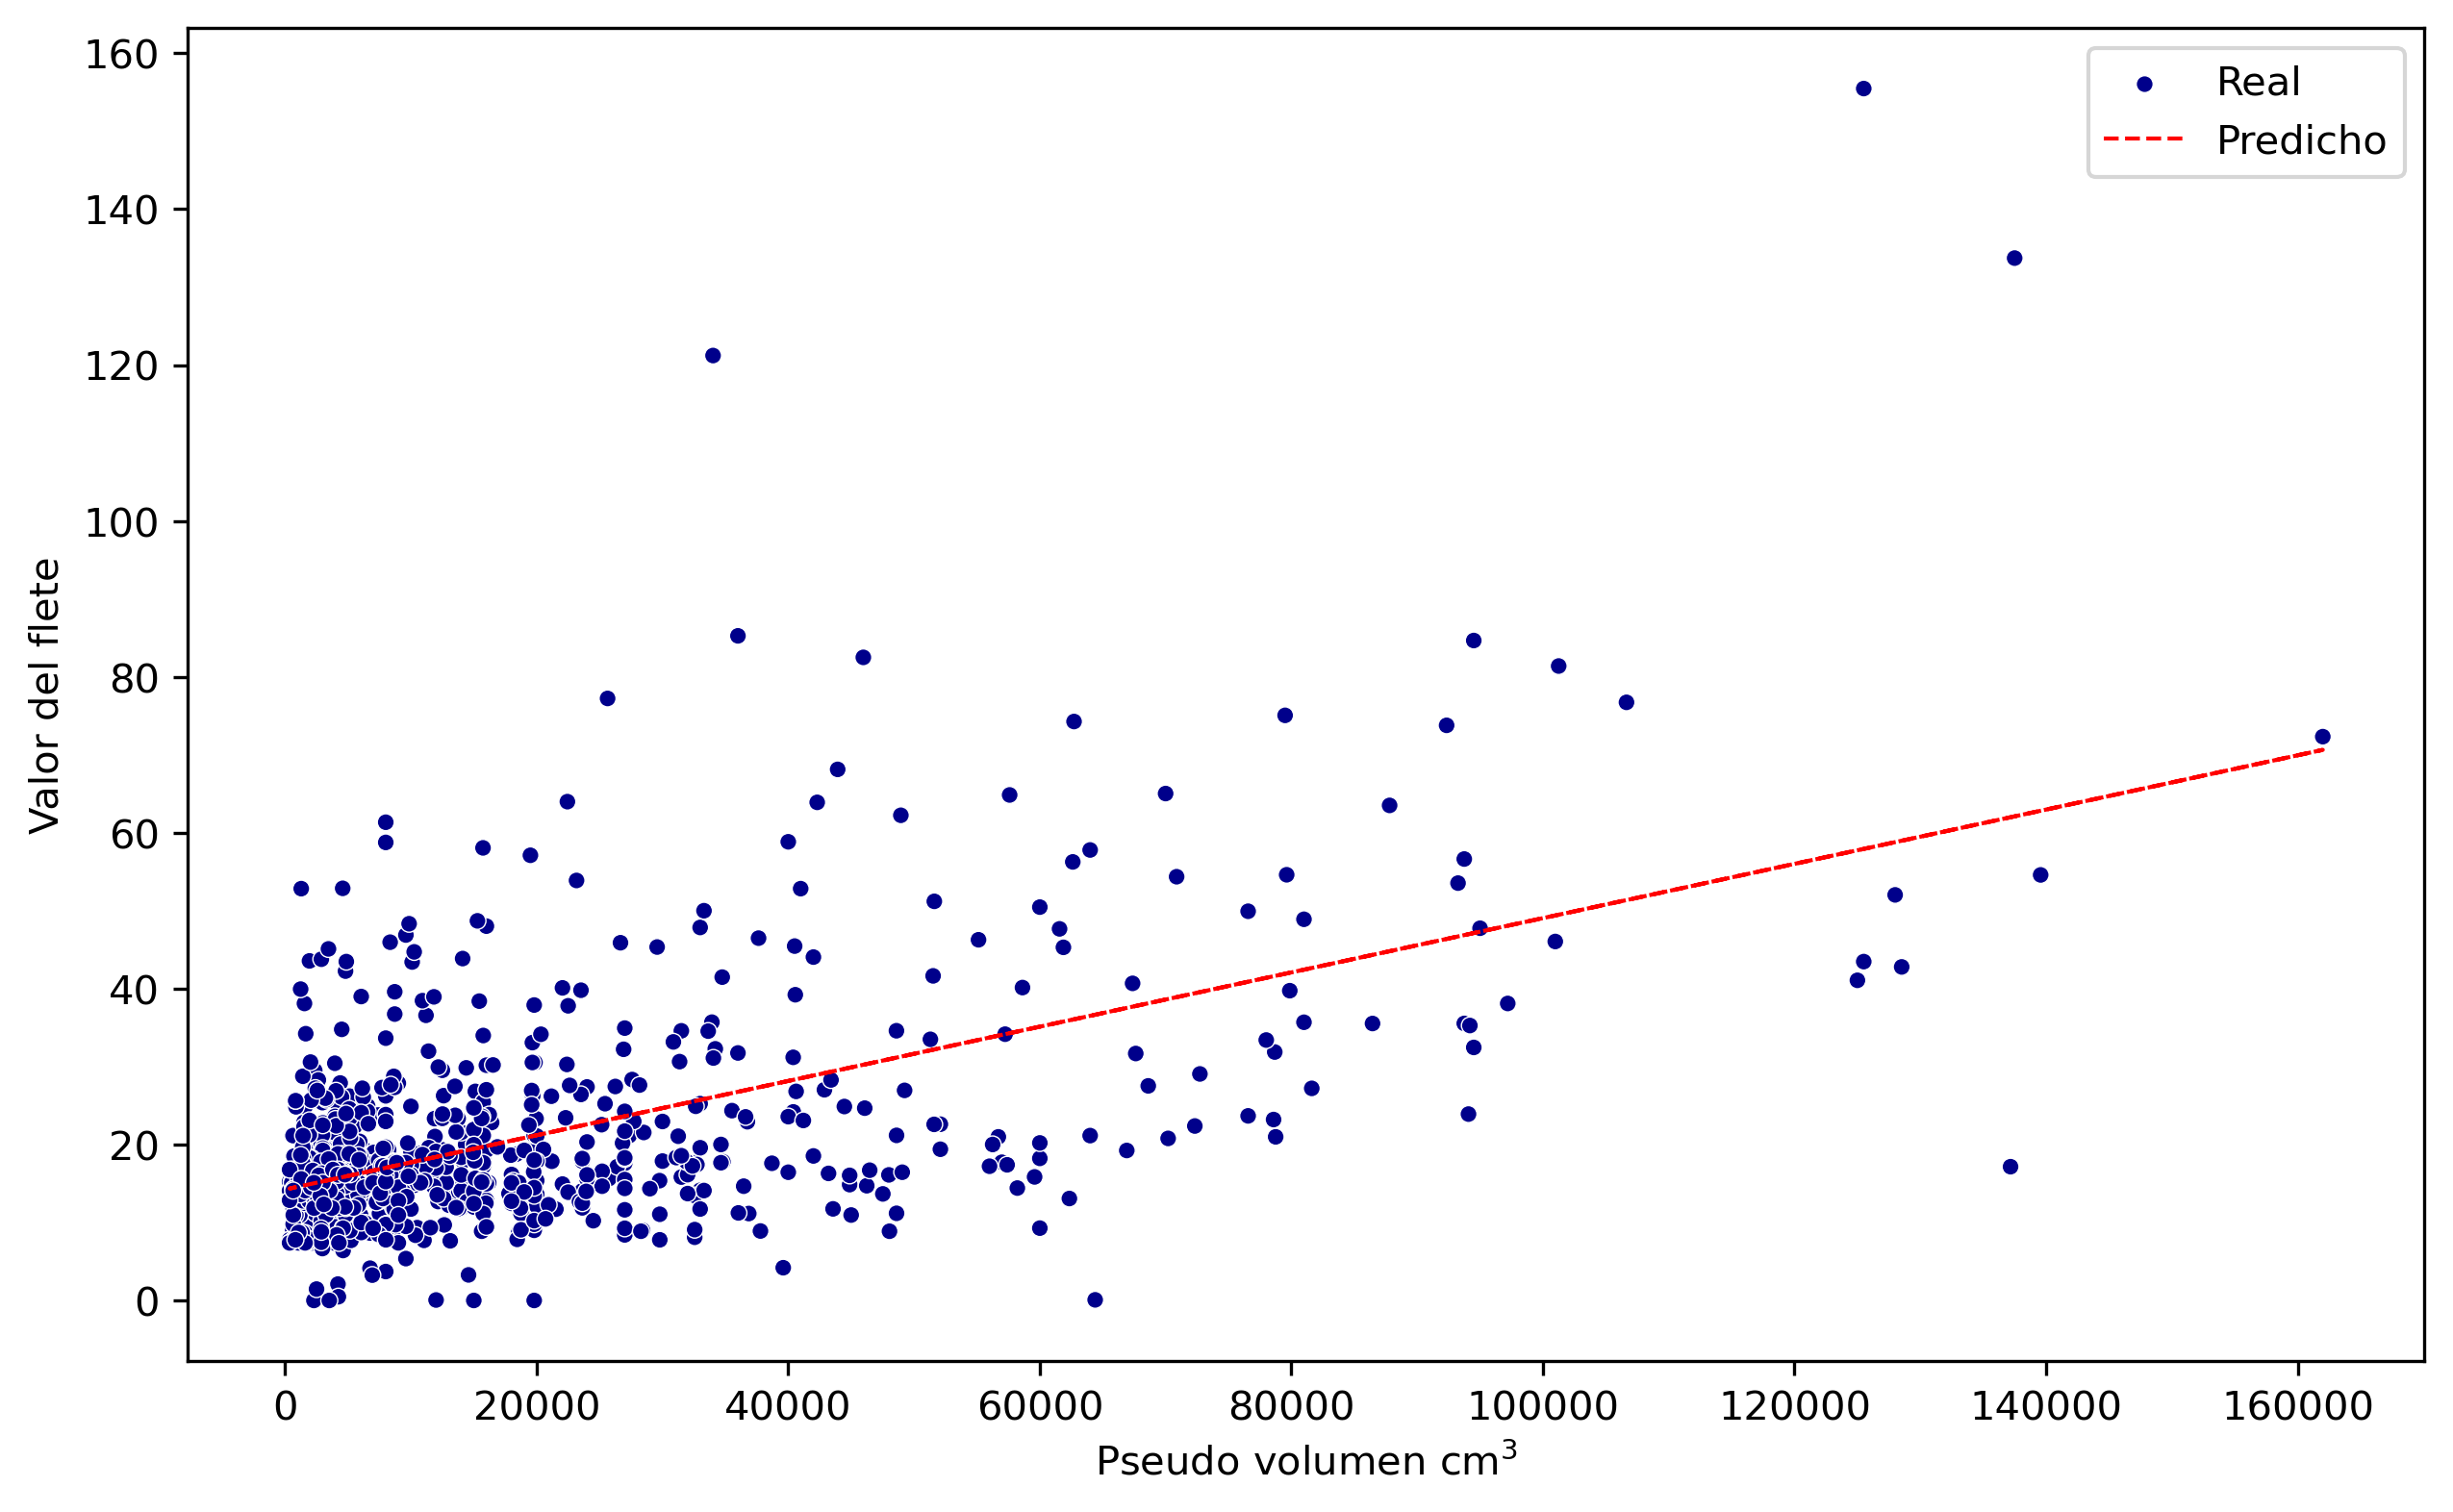

In [661]:
fig, ax = plt.subplots(figsize = (10, 6), dpi = 300)
sns.scatterplot(data = muestra, x = "pseudo_volumen", y = "freight_value", 
                color = "darkblue", size = 1, legend = False,
                ax = ax)
plt.plot(X["pseudo_volumen"], y_hat, color = 'red', linestyle = "--", linewidth = 1);
plt.legend(["Real", "Predicho"])
plt.xlabel("Pseudo volumen cm$^3$")
plt.ylabel("Valor del flete")

Text(0, 0.5, 'Valor del flete')

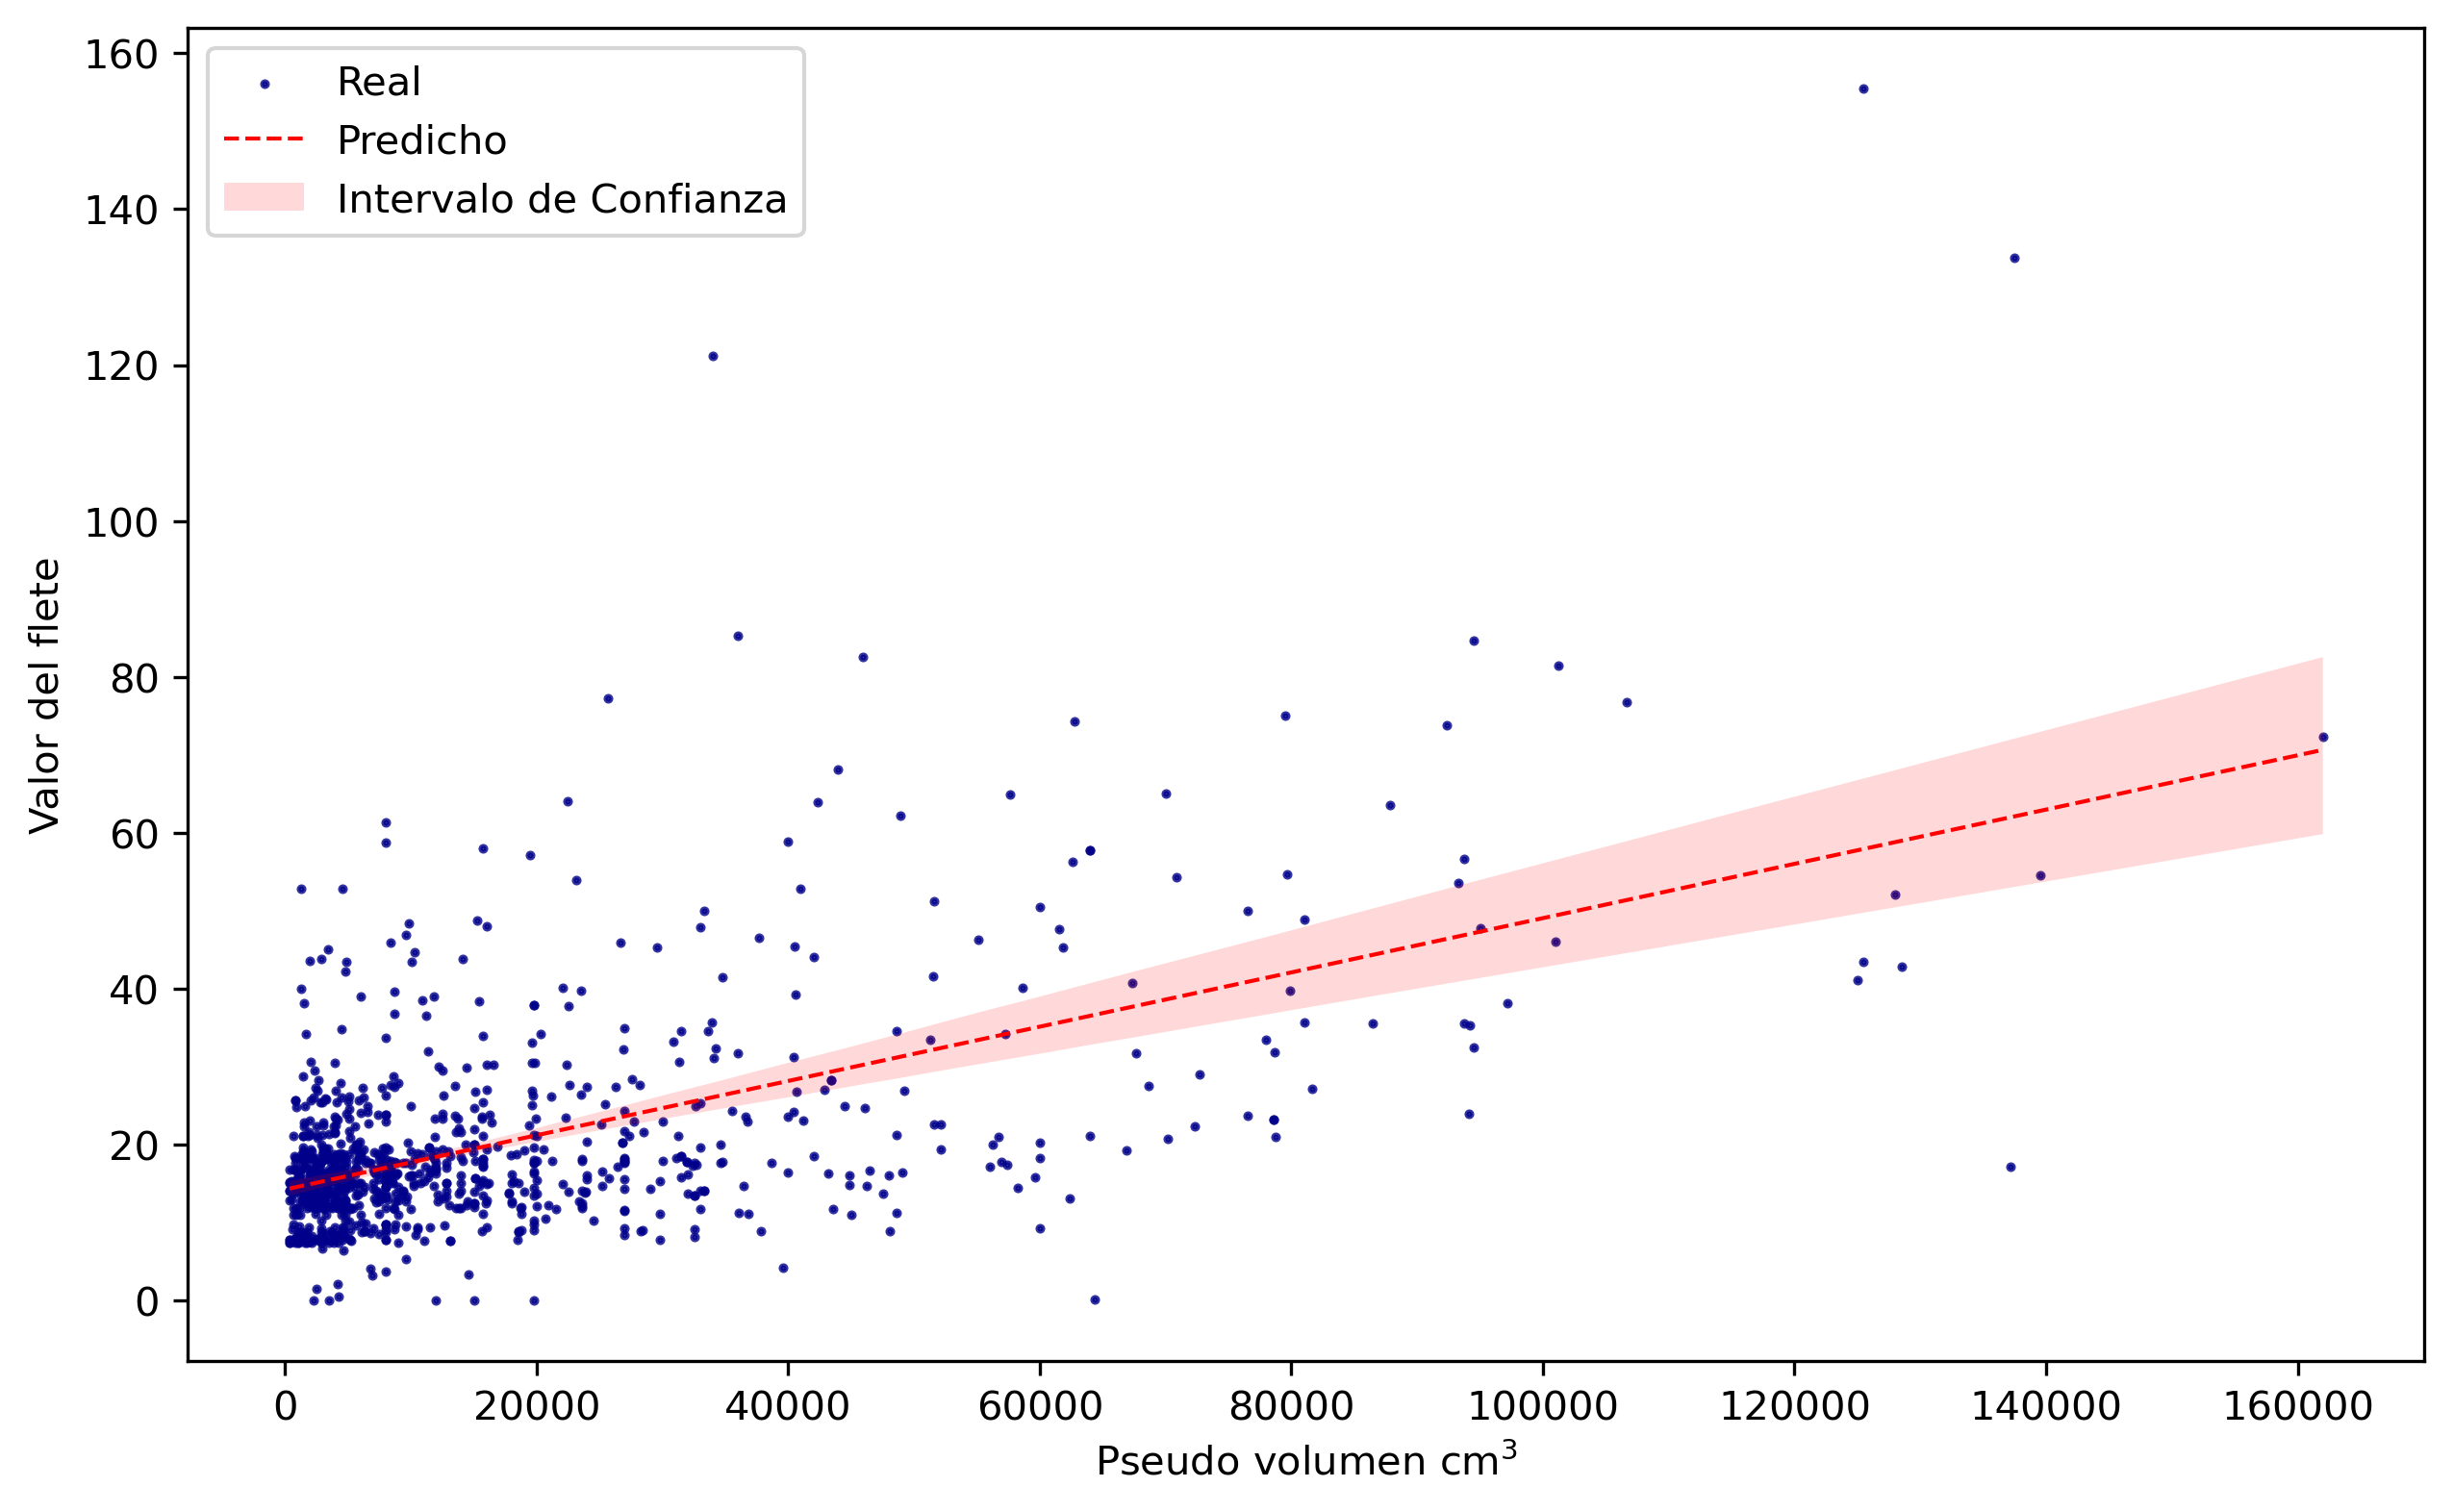

In [662]:
# Gráfico automático
fig, ax = plt.subplots(figsize = (10, 6), dpi = 300)
sns.regplot(x = "pseudo_volumen", y = "freight_value", data = muestra, ax = ax,
            scatter_kws = {"color": "darkblue", "s": 2}, 
            line_kws = {"color": "red", "linestyle": "--", "linewidth": 1})
plt.legend(["Real", "Predicho", "Intervalo de Confianza"])
plt.xlabel("Pseudo volumen cm$^3$")
plt.ylabel("Valor del flete")